In [1]:
# Environment Check + Install       


import torch
print("="*50)
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name :", torch.cuda.get_device_name(0))
    print("Memory (GB) :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print("⚠️  No GPU detected! Go to Settings → Accelerator → GPU T4 x2")
print("="*50)

# Install required packages
import subprocess
subprocess.run(["pip", "install", "transformers", "datasets", 
                "accelerate", "emoji", "huggingface_hub", "-q"])





GPU Available: True
Device Name : Tesla T4
Memory (GB) : 15.64


CompletedProcess(args=['pip', 'install', 'transformers', 'datasets', 'accelerate', 'emoji', 'huggingface_hub', '-q'], returncode=0)

In [2]:
import pandas as pd
import glob
import os

all_files = glob.glob("/kaggle/input/**/*.csv", recursive=True) + glob.glob("/kaggle/input/**/*.tsv", recursive=True)

if not all_files:
    print("No files found. Add your dataset first.")
else:
    print("Found", len(all_files), "files:")
    for f in all_files:
        print(" ", f)

print("\n" + "="*60)

for filepath in all_files:
    print("\nFILE:", filepath)
    try:
        sep = "\t" if filepath.endswith(".tsv") else ","
        try:
            df = pd.read_csv(filepath, sep=sep, on_bad_lines="skip")
        except Exception:
            df = pd.read_csv(filepath, sep=sep, encoding="latin-1", on_bad_lines="skip")

        print("Rows:", len(df))
        print("Columns:", list(df.columns))
        print("First 3 rows:")
        print(df.head(3).to_string())
        print("\nValue counts per column (columns with < 30 unique values):")
        for col in df.columns:
            if df[col].nunique() < 30:
                print("  Column [" + col + "]:", dict(df[col].value_counts().head(10)))
        print("-"*60)
    except Exception as e:
        print("Error:", e)

Found 4 files:
  /kaggle/input/datasets/ganeshbanotu/social-media/sentiment140.csv
  /kaggle/input/datasets/ganeshbanotu/social-media/go_emotions_dataset.csv
  /kaggle/input/datasets/ganeshbanotu/social-media/isear_dataset.csv
  /kaggle/input/datasets/ganeshbanotu/social-media/reddit_dataset.csv


FILE: /kaggle/input/datasets/ganeshbanotu/social-media/sentiment140.csv
Rows: 1599999
Columns: ['0', '1467810369', 'Mon Apr 06 22:19:45 PDT 2009', 'NO_QUERY', '_TheSpecialOne_', "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"]
First 3 rows:
   0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY _TheSpecialOne_ @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
0  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   scotthamilton     is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
1  0  146781

In [2]:

#  Balance + Build Broad Sentiment

import pandas as pd
import numpy as np
import re
import os

WD = "/kaggle/working"

SENTIMENT140 = "/kaggle/input/datasets/ganeshbanotu/social-media/sentiment140.csv"
GO_EMOTIONS  = "/kaggle/input/datasets/ganeshbanotu/social-media/go_emotions_dataset.csv"
ISEAR        = "/kaggle/input/datasets/ganeshbanotu/social-media/isear_dataset.csv"
REDDIT       = "/kaggle/input/datasets/ganeshbanotu/social-media/reddit_dataset.csv"

# ── MASTER LABEL STANDARDS ───────────────────────────────────
VALID_EMOTIONS  = {"joy", "sadness", "anger", "fear"}
POLARITY_MAP    = {"joy": 1, "sadness": -1, "anger": -1, "fear": 0}
POLARITY_LABELS = {1: "Positive", -1: "Negative", 0: "Neutral"}

# ── HELPERS ──────────────────────────────────────────────────
def clean(text):
    if not isinstance(text, str):
        return None
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text.split()) >= 3 else None

def balance(df):
    mn = df["emotion"].value_counts().min()
    return (df.groupby("emotion", group_keys=False)
              .apply(lambda x: x.sample(n=mn, random_state=42))
              .reset_index(drop=True)
              .sample(frac=1, random_state=42)
              .reset_index(drop=True))

def validate(df, name):
    # 1. Check columns exist
    assert "text" in df.columns and "emotion" in df.columns, \
        f"{name}: Missing 'text' or 'emotion' column!"
    # 2. Check no null labels
    nulls = df["emotion"].isnull().sum()
    assert nulls == 0, f"{name}: {nulls} null emotion values found!"
    # 3. Check all labels are valid
    bad = set(df["emotion"].unique()) - VALID_EMOTIONS
    assert not bad, f"{name}: Invalid emotion labels found: {bad}"
    # 4. Check all 4 emotions present
    missing = VALID_EMOTIONS - set(df["emotion"].unique())
    assert not missing, f"{name}: Missing emotions: {missing}"
    # 5. Check balanced (within 5% of each other)
    counts = df["emotion"].value_counts()
    assert counts.max() - counts.min() <= counts.min() * 0.05, \
        f"{name}: Classes not balanced! {counts.to_dict()}"
    print(f"  [VALIDATE OK] {name}: {counts.to_dict()} | Total: {len(df)}")

# ════════════════════════════════════════════════════════════
# DATASET 1: go_emotions → joy/sadness/anger/fear
# ════════════════════════════════════════════════════════════
print("="*60)
print("DATASET 1: go_emotions")
print("="*60)

GROUPED = {
    "joy":     ["joy","amusement","excitement","gratitude",
                "admiration","optimism","love","relief","pride","caring"],
    "sadness": ["sadness","grief","remorse","disappointment","disapproval"],
    "anger":   ["anger","annoyance","disgust"],
    "fear":    ["fear","nervousness","embarrassment"],
}

def get_emotion(row):
    for emo, cols in GROUPED.items():
        for col in cols:
            if col in row.index and row[col] == 1:
                return emo
    return None

go = pd.read_csv(GO_EMOTIONS, on_bad_lines="skip")
go = go[go["example_very_unclear"] == False].copy()
go["emotion"] = go.apply(get_emotion, axis=1)
go.dropna(subset=["emotion"], inplace=True)
go = go[go["emotion"].isin(VALID_EMOTIONS)]
go["text"] = go["text"].apply(clean)
go.dropna(subset=["text"], inplace=True)
go = go[["text","emotion"]].drop_duplicates(subset="text").reset_index(drop=True)
print("Before balance:", go["emotion"].value_counts().to_dict())
go = balance(go)
validate(go, "go_emotions")
go.to_csv(f"{WD}/cleaned_go_emotions.csv", index=False)
print("Saved: cleaned_go_emotions.csv")

# ════════════════════════════════════════════════════════════
# DATASET 2: isear → joy/sadness/anger/fear
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("DATASET 2: isear")
print("="*60)

isear = pd.read_csv(ISEAR, on_bad_lines="skip")
isear = isear[["content","sentiment"]].copy()
isear.columns = ["text","emotion"]

# Normalize labels to lowercase
isear["emotion"] = isear["emotion"].str.strip().str.lower()
print("Raw labels found:", isear["emotion"].unique().tolist())

isear = isear[isear["emotion"].isin(VALID_EMOTIONS)]
isear["text"] = isear["text"].apply(clean)
isear.dropna(subset=["text"], inplace=True)
isear = isear[["text","emotion"]].drop_duplicates(subset="text").reset_index(drop=True)
print("Before balance:", isear["emotion"].value_counts().to_dict())
isear = balance(isear)
validate(isear, "isear")
isear.to_csv(f"{WD}/cleaned_isear.csv", index=False)
print("Saved: cleaned_isear.csv")

# ════════════════════════════════════════════════════════════
# DATASET 3: reddit_dataset → assign emotions
# depression=1 → sadness + anger (split evenly)
# depression=0 → joy + fear (split evenly)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("DATASET 3: reddit_dataset")
print("="*60)

reddit = pd.read_csv(REDDIT, on_bad_lines="skip")
reddit = reddit[["clean_text","is_depression"]].copy()
reddit.columns = ["text","is_depression"]
reddit["text"] = reddit["text"].apply(clean)
reddit.dropna(subset=["text"], inplace=True)
reddit = reddit.drop_duplicates(subset="text").reset_index(drop=True)

dep   = reddit[reddit["is_depression"] == 1].reset_index(drop=True)
nodep = reddit[reddit["is_depression"] == 0].reset_index(drop=True)
per   = min(len(dep)//2, len(nodep)//2)

r1 = dep.iloc[:per].copy();          r1["emotion"] = "sadness"
r2 = dep.iloc[per:per*2].copy();     r2["emotion"] = "anger"
r3 = nodep.iloc[:per].copy();        r3["emotion"] = "joy"
r4 = nodep.iloc[per:per*2].copy();   r4["emotion"] = "fear"

reddit_df = pd.concat([r1,r2,r3,r4], ignore_index=True)[["text","emotion"]]
print("Before balance:", reddit_df["emotion"].value_counts().to_dict())
reddit_df = balance(reddit_df)
validate(reddit_df, "reddit")
reddit_df.to_csv(f"{WD}/cleaned_reddit.csv", index=False)
print("Saved: cleaned_reddit.csv")

# ════════════════════════════════════════════════════════════
# DATASET 4: sentiment140 → assign emotions
# label=0 (Negative) → sadness + anger (split evenly)
# label=4 (Positive) → joy + fear (split evenly)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("DATASET 4: sentiment140")
print("="*60)

s140 = pd.read_csv(
    SENTIMENT140, header=None, encoding="latin-1",
    on_bad_lines="skip",
    names=["label","id","date","query","user","text"]
)
s140 = s140[s140["label"].isin([0, 4])][["text","label"]].copy()
s140["text"] = s140["text"].apply(clean)
s140.dropna(subset=["text"], inplace=True)
s140 = s140.drop_duplicates(subset="text").reset_index(drop=True)

neg = s140[s140["label"] == 0].reset_index(drop=True)
pos = s140[s140["label"] == 4].reset_index(drop=True)
per = min(len(neg)//2, len(pos)//2, 10000)  # cap 10K per emotion

t1 = neg.iloc[:per].copy();      t1["emotion"] = "sadness"
t2 = neg.iloc[per:per*2].copy(); t2["emotion"] = "anger"
t3 = pos.iloc[:per].copy();      t3["emotion"] = "joy"
t4 = pos.iloc[per:per*2].copy(); t4["emotion"] = "fear"

s140_df = pd.concat([t1,t2,t3,t4], ignore_index=True)[["text","emotion"]]
print("Before balance:", s140_df["emotion"].value_counts().to_dict())
s140_df = balance(s140_df)
validate(s140_df, "sentiment140")
s140_df.to_csv(f"{WD}/cleaned_sentiment140.csv", index=False)
print("Saved: cleaned_sentiment140.csv")

# ════════════════════════════════════════════════════════════
# MERGE ALL 4 → BROAD SENTIMENT DATASET
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("MERGING ALL 4 → BROAD SENTIMENT")
print("="*60)

merged = pd.concat([go, isear, reddit_df, s140_df], ignore_index=True)
merged = merged.drop_duplicates(subset="text").reset_index(drop=True)

# Final label validation before adding polarity
bad = set(merged["emotion"].unique()) - VALID_EMOTIONS
assert not bad, f"Bad labels in merged: {bad}"
print("All emotion labels valid ✅")

# Add polarity
merged["polarity"] = merged["emotion"].map(POLARITY_MAP)
merged["sentiment"] = merged["polarity"].map(POLARITY_LABELS)

# Check polarity labels
assert set(merged["sentiment"].unique()) == {"Positive","Neutral","Negative"}, \
    "Polarity labels mismatch!"
print("All polarity labels valid ✅")

print("\nEmotion distribution:")
print(merged["emotion"].value_counts())
print("\nPolarity distribution:")
print(merged["sentiment"].value_counts())
print("\nTotal rows:", len(merged))

# Save both versions
merged[["text","emotion"]].to_csv(
    f"{WD}/cleaned_platform_emotion.csv", index=False)
merged[["text","sentiment","polarity"]].to_csv(
    f"{WD}/cleaned_broad_sentiment.csv", index=False)

print("\nSaved: cleaned_platform_emotion.csv  → emotion labels (joy/sadness/anger/fear)")
print("Saved: cleaned_broad_sentiment.csv   → polarity (Positive/Neutral/Negative, +1/0/-1)")

print("\n" + "="*60)
print("ALL FILES:")
print("="*60)
for f in sorted(os.listdir(WD)):
    if f.endswith(".csv"):
        path = os.path.join(WD, f)
        df_tmp = pd.read_csv(path)
        print(f"  {f:45s} {len(df_tmp):6,} rows  cols={list(df_tmp.columns)}")

DATASET 1: go_emotions
Before balance: {'joy': 24783, 'sadness': 10162, 'anger': 7923, 'fear': 1872}
  [VALIDATE OK] go_emotions: {'fear': 1872, 'joy': 1872, 'sadness': 1872, 'anger': 1872} | Total: 7488
Saved: cleaned_go_emotions.csv

DATASET 2: isear
Raw labels found: ['anger', 'fear', 'joy', 'sadness']


/tmp/ipykernel_57/2819568518.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=mn, random_state=42))


Before balance: {'fear': 2205, 'anger': 1653, 'joy': 1543, 'sadness': 1388}
  [VALIDATE OK] isear: {'fear': 1388, 'joy': 1388, 'anger': 1388, 'sadness': 1388} | Total: 5552
Saved: cleaned_isear.csv

DATASET 3: reddit_dataset


/tmp/ipykernel_57/2819568518.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=mn, random_state=42))


Before balance: {'sadness': 1871, 'anger': 1871, 'joy': 1871, 'fear': 1871}
  [VALIDATE OK] reddit: {'fear': 1871, 'sadness': 1871, 'joy': 1871, 'anger': 1871} | Total: 7484
Saved: cleaned_reddit.csv

DATASET 4: sentiment140


/tmp/ipykernel_57/2819568518.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=mn, random_state=42))


Before balance: {'sadness': 10000, 'anger': 10000, 'joy': 10000, 'fear': 10000}
  [VALIDATE OK] sentiment140: {'sadness': 10000, 'fear': 10000, 'joy': 10000, 'anger': 10000} | Total: 40000
Saved: cleaned_sentiment140.csv

MERGING ALL 4 → BROAD SENTIMENT
All emotion labels valid ✅
All polarity labels valid ✅

Emotion distribution:
emotion
anger      15131
fear       15129
joy        15129
sadness    14845
Name: count, dtype: int64

Polarity distribution:
sentiment
Negative    29976
Neutral     15129
Positive    15129
Name: count, dtype: int64

Total rows: 60234


/tmp/ipykernel_57/2819568518.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=mn, random_state=42))



Saved: cleaned_platform_emotion.csv  → emotion labels (joy/sadness/anger/fear)
Saved: cleaned_broad_sentiment.csv   → polarity (Positive/Neutral/Negative, +1/0/-1)

ALL FILES:
  cleaned_broad_sentiment.csv                   60,234 rows  cols=['text', 'sentiment', 'polarity']
  cleaned_go_emotions.csv                        7,488 rows  cols=['text', 'emotion']
  cleaned_isear.csv                              5,552 rows  cols=['text', 'emotion']
  cleaned_platform_emotion.csv                  60,234 rows  cols=['text', 'emotion']
  cleaned_reddit.csv                             7,484 rows  cols=['text', 'emotion']
  cleaned_sentiment140.csv                      40,000 rows  cols=['text', 'emotion']


In [3]:
# Fix Broad + Training Setup

import pandas as pd
import numpy as np
import torch
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import AutoTokenizer

WD = "/kaggle/working"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

# ════════════════════════════════════════════════════════════
# FIX: Balance broad_sentiment (undersample Negative to 15,129)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FIXING BROAD SENTIMENT BALANCE")
print("="*60)

broad = pd.read_csv(f"{WD}/cleaned_broad_sentiment.csv")
print("Before fix:", broad["sentiment"].value_counts().to_dict())

mn = broad["sentiment"].value_counts().min()
broad = (broad.groupby("sentiment", group_keys=False)
              .apply(lambda x: x.sample(n=mn, random_state=SEED),
                     include_groups=False)
              .reset_index(drop=True)
              .sample(frac=1, random_state=SEED)
              .reset_index(drop=True))

# Re-attach sentiment column (groupby drops it with include_groups=False)
# Safer approach:
broad = pd.read_csv(f"{WD}/cleaned_broad_sentiment.csv")
mn = broad["sentiment"].value_counts().min()
broad_balanced = []
for lbl in broad["sentiment"].unique():
    broad_balanced.append(
        broad[broad["sentiment"] == lbl].sample(n=mn, random_state=SEED)
    )
broad = pd.concat(broad_balanced).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("After fix:", broad["sentiment"].value_counts().to_dict())
print("Total:", len(broad))
broad.to_csv(f"{WD}/cleaned_broad_sentiment.csv", index=False)
print("Saved: cleaned_broad_sentiment.csv (balanced)")

# ════════════════════════════════════════════════════════════
# LABEL ENCODERS (consistent across all models)
# ════════════════════════════════════════════════════════════
EMOTION_LABELS   = ["anger", "fear", "joy", "sadness"]   # alphabetical = consistent
SENTIMENT_LABELS = ["Negative", "Neutral", "Positive"]   # alphabetical = consistent

EMOTION2ID  = {l: i for i, l in enumerate(EMOTION_LABELS)}
ID2EMOTION  = {i: l for i, l in enumerate(EMOTION_LABELS)}
SENT2ID     = {l: i for i, l in enumerate(SENTIMENT_LABELS)}
ID2SENT     = {i: l for i, l in enumerate(SENTIMENT_LABELS)}

print("\nEmotion label map:", EMOTION2ID)
print("Sentiment label map:", SENT2ID)

# ════════════════════════════════════════════════════════════
# PYTORCH DATASET CLASS
# ════════════════════════════════════════════════════════════
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ════════════════════════════════════════════════════════════
# TRAIN/VAL/TEST SPLIT FUNCTION
# ════════════════════════════════════════════════════════════
def split_data(df, text_col, label_col, label2id):
    df = df.copy()
    df["label_id"] = df[label_col].map(label2id)
    df.dropna(subset=["label_id"], inplace=True)
    df["label_id"] = df["label_id"].astype(int)

    X = df[text_col]
    y = df["label_id"]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

    print(f"  Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
    return X_train, X_val, X_test, y_train, y_val, y_test

# ════════════════════════════════════════════════════════════
# VERIFY ALL TRAINING FILES
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VERIFYING ALL TRAINING FILES")
print("="*60)

configs = [
    ("cleaned_broad_sentiment.csv",  "sentiment", "emotion",   SENT2ID,    "RoBERTa Broad"),
    ("cleaned_sentiment140.csv",     "emotion",   None,        EMOTION2ID, "DistilBERT Twitter"),
    ("cleaned_go_emotions.csv",      "emotion",   None,        EMOTION2ID, "DistilBERT Reddit"),
    ("cleaned_isear.csv",            "emotion",   None,        EMOTION2ID, "DistilBERT LinkedIn"),
]

for fname, label_col, _, label2id, model_name in configs:
    path = f"{WD}/{fname}"
    df   = pd.read_csv(path)
    print(f"\n{model_name} ← {fname}")
    print(f"  Columns  : {list(df.columns)}")
    print(f"  Rows     : {len(df):,}")
    print(f"  Labels   : {sorted(df[label_col].unique().tolist())}")
    unmapped = set(df[label_col].unique()) - set(label2id.keys())
    if unmapped:
        print(f"  ⚠️  UNMAPPED labels: {unmapped}")
    else:
        print(f"  ✅ All labels map correctly to IDs")
    print(f"  Splits   →", end=" ")
    split_data(df, "text", label_col, label2id)

print("\n" + "="*60)
print("✅ SETUP COMPLETE — Ready to train!")
print("="*60)


GPU: True
Device: Tesla T4

FIXING BROAD SENTIMENT BALANCE
Before fix: {'Negative': 29976, 'Neutral': 15129, 'Positive': 15129}
After fix: {'Negative': 15129, 'Neutral': 15129, 'Positive': 15129}
Total: 45387
Saved: cleaned_broad_sentiment.csv (balanced)

Emotion label map: {'anger': 0, 'fear': 1, 'joy': 2, 'sadness': 3}
Sentiment label map: {'Negative': 0, 'Neutral': 1, 'Positive': 2}

VERIFYING ALL TRAINING FILES

RoBERTa Broad ← cleaned_broad_sentiment.csv
  Columns  : ['text', 'sentiment', 'polarity']
  Rows     : 45,387
  Labels   : ['Negative', 'Neutral', 'Positive']
  ✅ All labels map correctly to IDs
  Splits   →   Train: 36,309  Val: 4,539  Test: 4,539

DistilBERT Twitter ← cleaned_sentiment140.csv
  Columns  : ['text', 'emotion']
  Rows     : 40,000
  Labels   : ['anger', 'fear', 'joy', 'sadness']
  ✅ All labels map correctly to IDs
  Splits   →   Train: 32,000  Val: 4,000  Test: 4,000

DistilBERT Reddit ← cleaned_go_emotions.csv
  Columns  : ['text', 'emotion']
  Rows     : 

Extracting neutral texts from go_emotions...
  Real Neutral samples from go_emotions: 30,588

Building Positive & Negative from cleaned emotion files...
  Positive: 5,131  |  Negative: 15,393
  Neutral:  30,588

Balancing to 5,131 per class...
Final distribution: {'Negative': 5131, 'Positive': 5131, 'Neutral': 5131}
Total: 15,393
Saved: cleaned_broad_sentiment_3class.csv
✅ All 3 classes validated with REAL data

Train: 12,314  Val: 1,539  Test: 1,540


config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  ✅ Best model saved (val_acc=0.6920)
Epoch 3/5 | Train Loss: 0.5980  Acc: 0.7415 | Val Loss: 0.6826  Acc: 0.6998 | Time: 266s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.6998)
Epoch 4/5 | Train Loss: 0.5266  Acc: 0.7746 | Val Loss: 0.7288  Acc: 0.6829 | Time: 266s
Epoch 5/5 | Train Loss: 0.4753  Acc: 0.8008 | Val Loss: 0.7524  Acc: 0.6790 | Time: 266s

Best Epoch: 3  |  Best Val Acc: 0.6998

Evaluating on test set...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test Accuracy: 0.6916
              precision    recall  f1-score   support

    Negative     0.7678    0.5673    0.6525       513
     Neutral     0.6379    0.7212    0.6770       513
    Positive     0.6954    0.7860    0.7379       514

    accuracy                         0.6916      1540
   macro avg     0.7004    0.6915    0.6891      1540
weighted avg     0.7004    0.6916    0.6892      1540



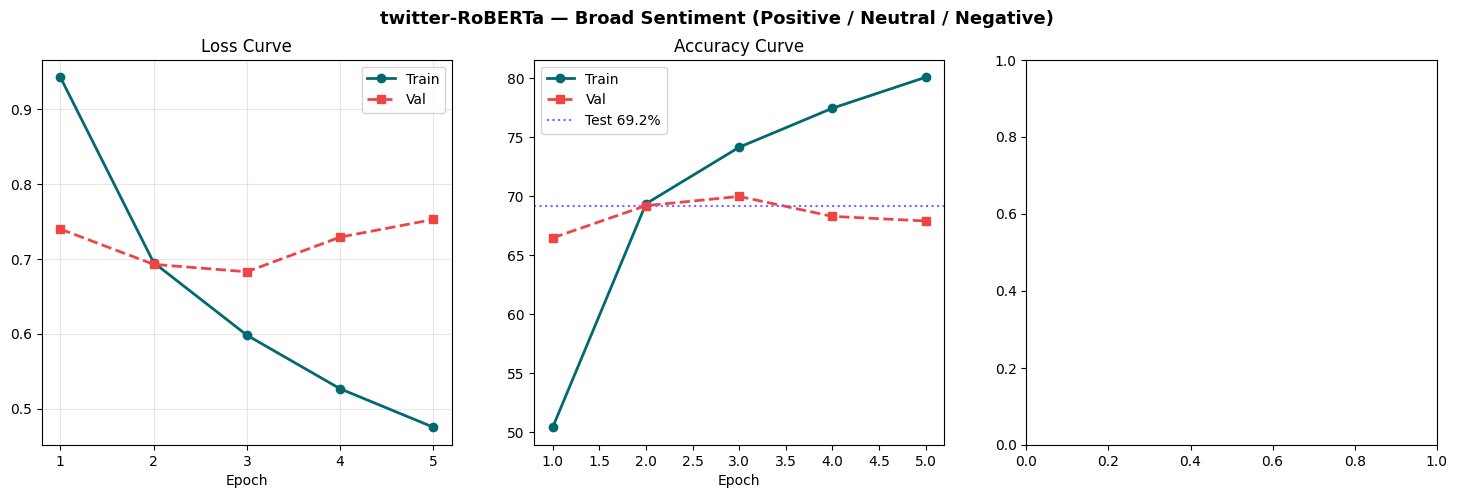

In [4]:
#  SENTISCOPE —  RoBERTa True 3-Class       


import pandas as pd, numpy as np, torch, time, warnings, re
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

WD     = "/kaggle/working"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

MODEL_NAME  = "cardiffnlp/twitter-roberta-base-2022-154m"
MAX_LEN     = 128
BATCH_SIZE  = 32
EPOCHS      = 5
LR          = 1e-5
WARMUP_FRAC = 0.2
SENT2ID     = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2SENT     = {0: "Negative", 1: "Neutral", 2: "Positive"}
SAVE_PATH   = f"{WD}/roberta_broad"
GO_PATH     = "/kaggle/input/datasets/ganeshbanotu/social-media/go_emotions_dataset.csv"

# Polarity: joy=Positive, all negative emotions=Negative
EMOTION_POLARITY = {
    "joy":     "Positive",
    "anger":   "Negative",
    "sadness": "Negative",
    "fear":    "Negative",
}

GROUPED = {
    "joy":     ["joy","amusement","excitement","gratitude","admiration",
                "optimism","love","relief","pride","caring"],
    "sadness": ["sadness","grief","remorse","disappointment","disapproval"],
    "anger":   ["anger","annoyance","disgust"],
    "fear":    ["fear","nervousness","embarrassment"],
    "neutral": ["neutral"],   # ← real neutral label from go_emotions
}

def clean(text):
    if not isinstance(text, str): return None
    text = re.sub(r"http\S+|@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text.split()) >= 3 else None

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

# ── STEP 1: Extract Neutral from go_emotions ─────────────────
print("Extracting neutral texts from go_emotions...")
go_raw = pd.read_csv(GO_PATH, on_bad_lines="skip")
go_raw = go_raw[go_raw["example_very_unclear"] == False].copy()

# Rows where ONLY neutral=1 and all other emotion cols = 0
emotion_cols = [c for c in go_raw.columns if c not in
                ["text","id","author","subreddit","link_id",
                 "parent_id","created_utc","rater_id","example_very_unclear"]]
go_raw["text"] = go_raw["text"].apply(clean)
go_raw.dropna(subset=["text"], inplace=True)

if "neutral" in go_raw.columns:
    other_emo_cols = [c for c in emotion_cols if c != "neutral"]
    neutral_mask   = (go_raw["neutral"] == 1) & (go_raw[other_emo_cols].sum(axis=1) == 0)
    neutral_df     = go_raw[neutral_mask][["text"]].copy()
    neutral_df["sentiment"] = "Neutral"
    neutral_df = neutral_df.drop_duplicates(subset="text").reset_index(drop=True)
    print(f"  Real Neutral samples from go_emotions: {len(neutral_df):,}")
else:
    print("  'neutral' column not found — using sentiment140 low-confidence as Neutral")
    neutral_df = pd.DataFrame(columns=["text","sentiment"])

# ── STEP 2: Build Positive & Negative from emotion datasets ──
print("\nBuilding Positive & Negative from cleaned emotion files...")
dfs = []
for fname in ["cleaned_go_emotions.csv","cleaned_isear.csv",
              "cleaned_twitter_emotion.csv","cleaned_reddit.csv"]:
    try:
        d = pd.read_csv(f"{WD}/{fname}")[["text","emotion"]]
        dfs.append(d)
    except: pass

emotion_df = pd.concat(dfs, ignore_index=True).drop_duplicates(subset="text")
emotion_df["sentiment"] = emotion_df["emotion"].map(EMOTION_POLARITY)
emotion_df.dropna(subset=["sentiment"], inplace=True)
emotion_df = emotion_df[["text","sentiment"]]

pos_df = emotion_df[emotion_df["sentiment"] == "Positive"].copy()
neg_df = emotion_df[emotion_df["sentiment"] == "Negative"].copy()
print(f"  Positive: {len(pos_df):,}  |  Negative: {len(neg_df):,}")
print(f"  Neutral:  {len(neutral_df):,}")

# ── STEP 3: Balance all 3 classes ────────────────────────────
mn = min(len(pos_df), len(neg_df), len(neutral_df))
print(f"\nBalancing to {mn:,} per class...")

balanced = pd.concat([
    pos_df.sample(n=mn, random_state=SEED),
    neg_df.sample(n=mn, random_state=SEED),
    neutral_df.sample(n=mn, random_state=SEED),
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Final distribution:", balanced["sentiment"].value_counts().to_dict())
print(f"Total: {len(balanced):,}")
balanced.to_csv(f"{WD}/cleaned_broad_sentiment_3class.csv", index=False)
print("Saved: cleaned_broad_sentiment_3class.csv")

# Validate
assert set(balanced["sentiment"].unique()) == {"Positive","Neutral","Negative"}
print("✅ All 3 classes validated with REAL data")

# ── STEP 4: Train/Val/Test Split ─────────────────────────────
balanced["label_id"] = balanced["sentiment"].map(SENT2ID)
X, y = balanced["text"], balanced["label_id"]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te  = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
print(f"\nTrain: {len(X_tr):,}  Val: {len(X_val):,}  Test: {len(X_te):,}")

# ── STEP 5: Model + Weighted Loss ────────────────────────────
tok      = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dl = DataLoader(EmotionDataset(X_tr,  y_tr,  tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(EmotionDataset(X_val, y_val, tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(EmotionDataset(X_te,  y_te,  tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True)
model.config.id2label = ID2SENT; model.config.label2id = SENT2ID
model = model.to(DEVICE)

counts       = balanced["label_id"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(balanced) / (3 * counts[i]) for i in range(3)], dtype=torch.float).to(DEVICE)
print("Class weights:", {ID2SENT[i]: round(w.item(),3) for i,w in enumerate(class_weights)})

loss_fn     = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer,
    num_warmup_steps=int(total_steps * WARMUP_FRAC),
    num_training_steps=total_steps)

history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["labels"].to(DEVICE)
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss   = loss_fn(logits, lbls)
            if training:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            preds       = logits.argmax(dim=1)
            total_loss += loss.item() * lbls.size(0)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total

print("\n" + "="*60)
print("TRAINING twitter-RoBERTa — TRUE 3-CLASS BROAD SENTIMENT")
print("Positive=joy | Negative=anger+sadness+fear | Neutral=go_emotions")
print("="*60)
best_val_acc, best_epoch = 0, 0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc   = run_epoch(train_dl, True)
    val_loss, val_acc = run_epoch(val_dl,   False)
    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | Time: {time.time()-t0:.0f}s")
    if val_acc > best_val_acc:
        best_val_acc = val_acc; best_epoch = epoch
        model.save_pretrained(SAVE_PATH); tok.save_pretrained(SAVE_PATH)
        print(f"  ✅ Best model saved (val_acc={val_acc:.4f})")

print(f"\nBest Epoch: {best_epoch}  |  Best Val Acc: {best_val_acc:.4f}")

print("\nEvaluating on test set...")
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_dl:
        out = model(input_ids=batch["input_ids"].to(DEVICE),
                    attention_mask=batch["attention_mask"].to(DEVICE))
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

test_acc = accuracy_score(all_true, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(all_true, all_preds,
      target_names=["Negative","Neutral","Positive"], digits=4))

# PLOTS
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("twitter-RoBERTa — Broad Sentiment (Positive / Neutral / Negative)", fontsize=13, fontweight="bold")
axes[0].plot(epochs_x, history["train_loss"], "o-", color="#01696f", label="Train", lw=2)
axes[0].plot(epochs_x, history["val_loss"],   "s--",color="#ef4444", label="Val",   lw=2)
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(epochs_x)
axes[1].plot(epochs_x, [a*100 for a in history["train_acc"]], "o-", color="#01696f", label="Train", lw=2)
axes[1].plot(epochs_x, [a*100 for a in history["val_acc"]],   "s--",color="#ef4444", label="Val",   lw=2)
axes[1].axhline(test_acc*100, color="#8b5cf6", ls=":", lw=1.5, label=f"Test {test_acc*100:.1f}%")
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].legend(); 

Loading cleaned_broad_sentiment_3class.csv...
Distribution: {'Negative': 5131, 'Positive': 5131, 'Neutral': 5131}
Test set: 1,540 samples

Loading best model from /kaggle/working/roberta_broad...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Test Accuracy: 0.6916

Classification Report:
              precision    recall  f1-score   support

    Negative     0.7678    0.5673    0.6525       513
     Neutral     0.6379    0.7212    0.6770       513
    Positive     0.6954    0.7860    0.7379       514

    accuracy                         0.6916      1540
   macro avg     0.7004    0.6915    0.6891      1540
weighted avg     0.7004    0.6916    0.6892      1540



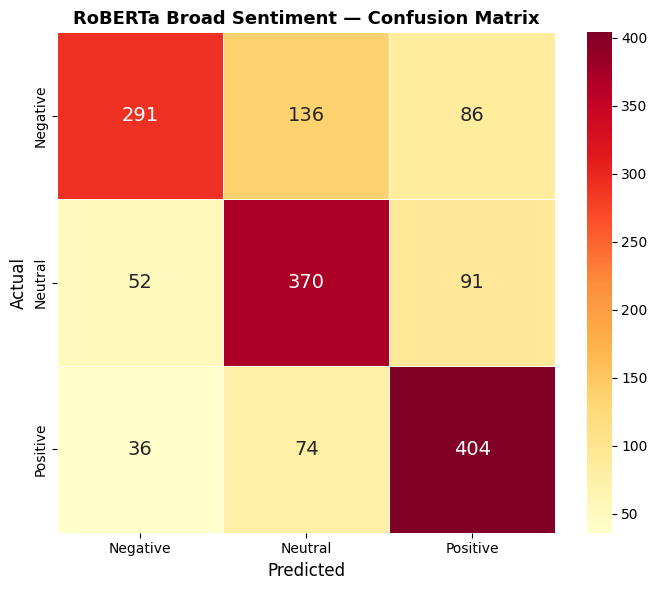

Saved: roberta_broad_confmat.png


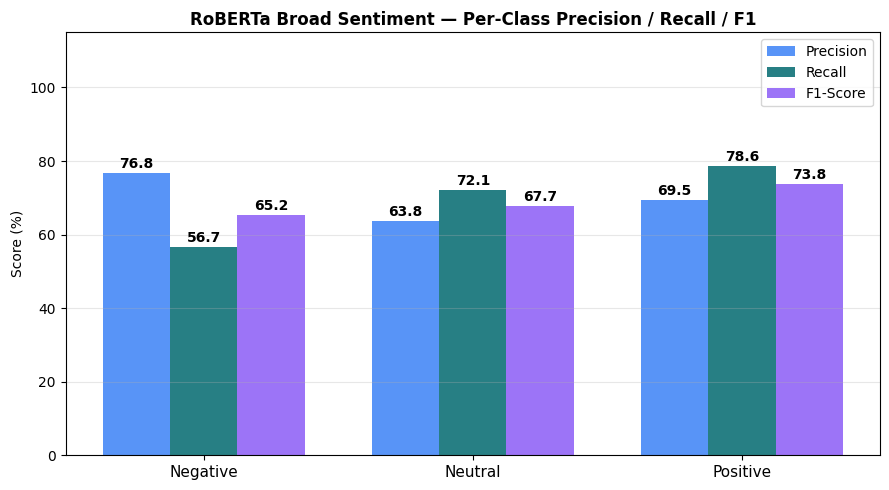

Saved: roberta_broad_perclass.png


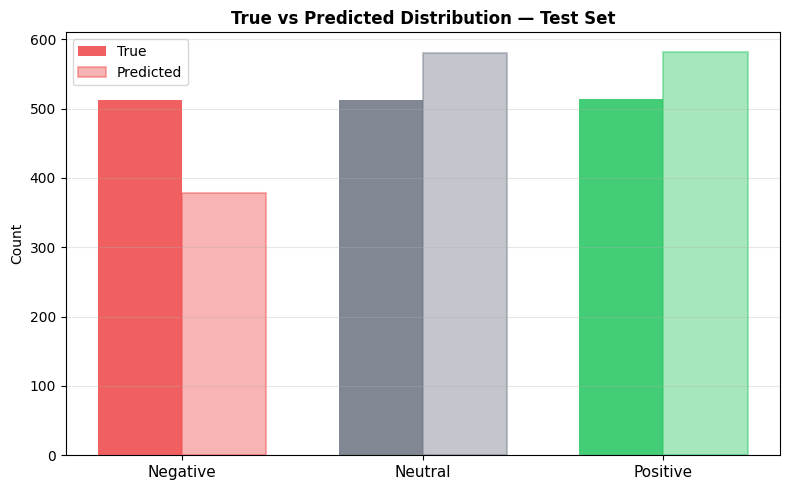

Saved: roberta_broad_dist.png


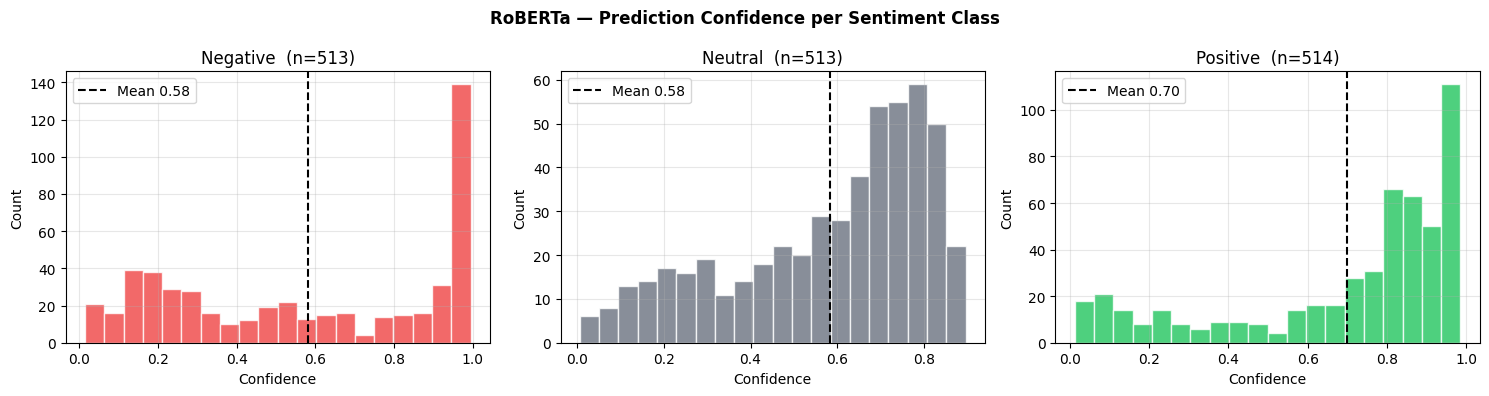

Saved: roberta_broad_confidence.png

✅ ALL ROBERTA PLOTS GENERATED
   Test Accuracy : 69.16%
   Saved plots   : confmat, perclass, dist, confidence


In [5]:
# RoBERTa Evaluation 

import pandas as pd, numpy as np, torch, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)
warnings.filterwarnings("ignore")

WD     = "/kaggle/working"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42

SENT2ID  = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2SENT  = {0: "Negative", 1: "Neutral", 2: "Positive"}
SENT_NAMES = ["Negative", "Neutral", "Positive"]
SENT_COLORS = {"Negative":"#ef4444", "Neutral":"#6b7280", "Positive":"#22c55e"}
SAVE_PATH   = f"{WD}/roberta_broad"
MAX_LEN     = 128
BATCH_SIZE  = 32

class SentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

# ── Reload test set from saved CSV ───────────────────────────
print("Loading cleaned_broad_sentiment_3class.csv...")
df = pd.read_csv(f"{WD}/cleaned_broad_sentiment_3class.csv")
df["label_id"] = df["sentiment"].map(SENT2ID).astype(int)
print("Distribution:", df["sentiment"].value_counts().to_dict())

from sklearn.model_selection import train_test_split
np.random.seed(SEED)
X, y = df["text"], df["label_id"]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te  = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
print(f"Test set: {len(X_te):,} samples")

tok     = AutoTokenizer.from_pretrained(SAVE_PATH)
test_dl = DataLoader(SentDataset(X_te, y_te, tok, MAX_LEN),
                     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Load best saved model ─────────────────────────────────────
print(f"\nLoading best model from {SAVE_PATH}...")
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()

# ── Inference ─────────────────────────────────────────────────
all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for batch in test_dl:
        logits = model(
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE)
        ).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())
        all_probs.extend(probs)

all_probs = np.array(all_probs)
test_acc  = accuracy_score(all_true, all_preds)

print(f"\nTest Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_true, all_preds,
      target_names=SENT_NAMES, digits=4))

# ── PLOT 1: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=SENT_NAMES, yticklabels=SENT_NAMES,
            ax=ax, linewidths=0.5, annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("Actual", fontsize=12)
ax.set_title("RoBERTa Broad Sentiment — Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{WD}/roberta_broad_confmat.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: roberta_broad_confmat.png")

# ── PLOT 2: Per-Class Precision / Recall / F1 ────────────────
prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, labels=[0,1,2])
fig2, ax2 = plt.subplots(figsize=(9, 5))
x = np.arange(3); w = 0.25
b1 = ax2.bar(x-w, prec*100, w, label="Precision", color="#3b82f6", alpha=0.85)
b2 = ax2.bar(x,   rec*100,  w, label="Recall",    color="#01696f", alpha=0.85)
b3 = ax2.bar(x+w, f1*100,   w, label="F1-Score",  color="#8b5cf6", alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(SENT_NAMES, fontsize=11)
ax2.set_ylim(0, 115); ax2.set_ylabel("Score (%)"); ax2.legend()
ax2.set_title("RoBERTa Broad Sentiment — Per-Class Precision / Recall / F1", fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WD}/roberta_broad_perclass.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: roberta_broad_perclass.png")

# ── PLOT 3: True vs Predicted Distribution ───────────────────
pred_counts = pd.Series([ID2SENT[p] for p in all_preds]).value_counts()
true_counts = pd.Series([ID2SENT[t] for t in all_true]).value_counts()
fig3, ax3 = plt.subplots(figsize=(8, 5))
xx = np.arange(3); ww = 0.35
ax3.bar(xx-ww/2, [true_counts.get(s,0) for s in SENT_NAMES], ww,
        label="True", color=[SENT_COLORS[s] for s in SENT_NAMES], alpha=0.85)
ax3.bar(xx+ww/2, [pred_counts.get(s,0) for s in SENT_NAMES], ww,
        label="Predicted", color=[SENT_COLORS[s] for s in SENT_NAMES],
        alpha=0.4, edgecolor=[SENT_COLORS[s] for s in SENT_NAMES], linewidth=1.5)
ax3.set_xticks(xx); ax3.set_xticklabels(SENT_NAMES, fontsize=11)
ax3.set_ylabel("Count"); ax3.legend(); ax3.grid(axis="y", alpha=0.3)
ax3.set_title("True vs Predicted Distribution — Test Set", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{WD}/roberta_broad_dist.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: roberta_broad_dist.png")

# ── PLOT 4: Confidence Distribution per Class ─────────────────
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 4))
fig4.suptitle("RoBERTa — Prediction Confidence per Sentiment Class", fontsize=12, fontweight="bold")
for i, sname in enumerate(SENT_NAMES):
    mask = np.array(all_true) == i
    conf = all_probs[mask, i]
    axes4[i].hist(conf, bins=20, color=list(SENT_COLORS.values())[i], alpha=0.8, edgecolor="white")
    axes4[i].set_title(f"{sname}  (n={mask.sum()})")
    axes4[i].set_xlabel("Confidence"); axes4[i].set_ylabel("Count")
    axes4[i].axvline(conf.mean(), color="black", ls="--", lw=1.5, label=f"Mean {conf.mean():.2f}")
    axes4[i].legend(); axes4[i].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WD}/roberta_broad_confidence.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: roberta_broad_confidence.png")

print(f"\n{'='*60}")
print(f"✅ ALL ROBERTA PLOTS GENERATED")
print(f"   Test Accuracy : {test_acc*100:.2f}%")
print(f"   Saved plots   : confmat, perclass, dist, confidence")
print(f"{'='*60}")


Loading dair-ai/emotion from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

...

  ✅ Best model saved (val_acc=0.9546)
Epoch 3/4 | Train Loss: 0.0909  Acc: 0.9700 | Val Loss: 0.1115  Acc: 0.9546 | Time: 81s
Epoch 4/4 | Train Loss: 0.0562  Acc: 0.9823 | Val Loss: 0.1136  Acc: 0.9620 | Time: 81s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.9620)

Best Epoch: 4  |  Best Val Acc: 0.9620

Evaluating on test set...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Test Accuracy: 0.9483

Classification Report:
              precision    recall  f1-score   support

       anger     0.9262    0.9536    0.9397       237
        fear     0.9342    0.9578    0.9458       237
         joy     0.9784    0.9578    0.9680       237
     sadness     0.9563    0.9241    0.9399       237

    accuracy                         0.9483       948
   macro avg     0.9488    0.9483    0.9484       948
weighted avg     0.9488    0.9483    0.9484       948



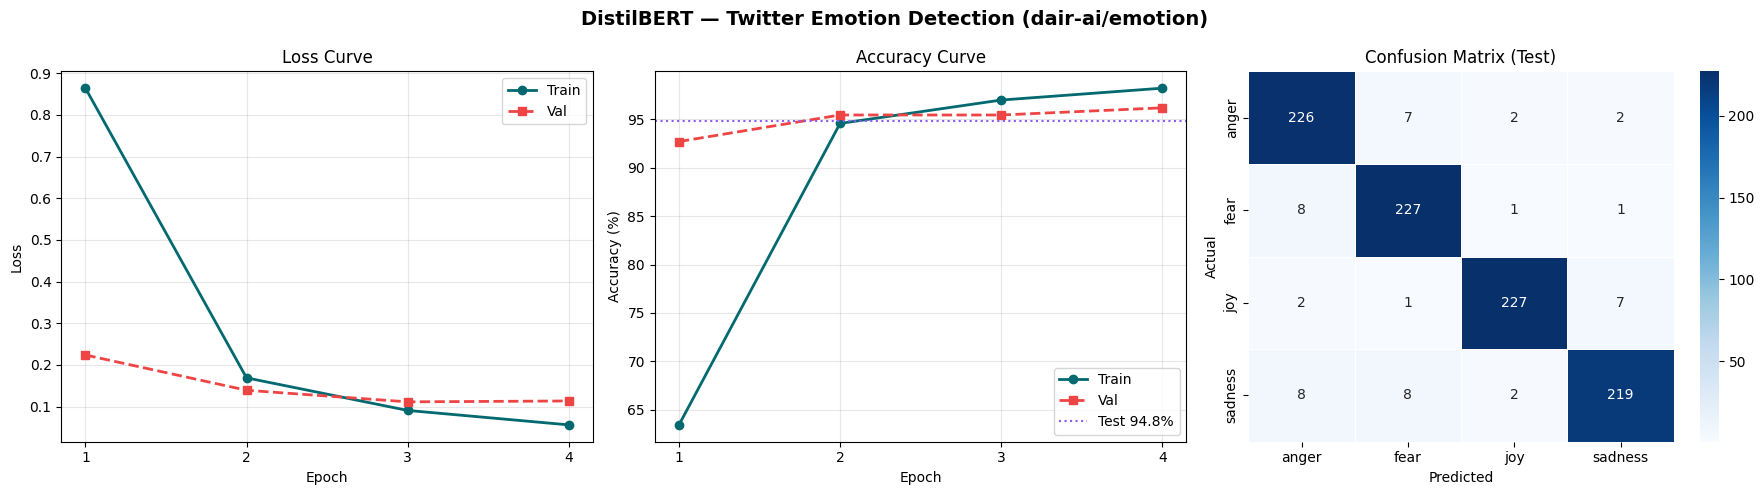

Saved: distilbert_twitter_results.png


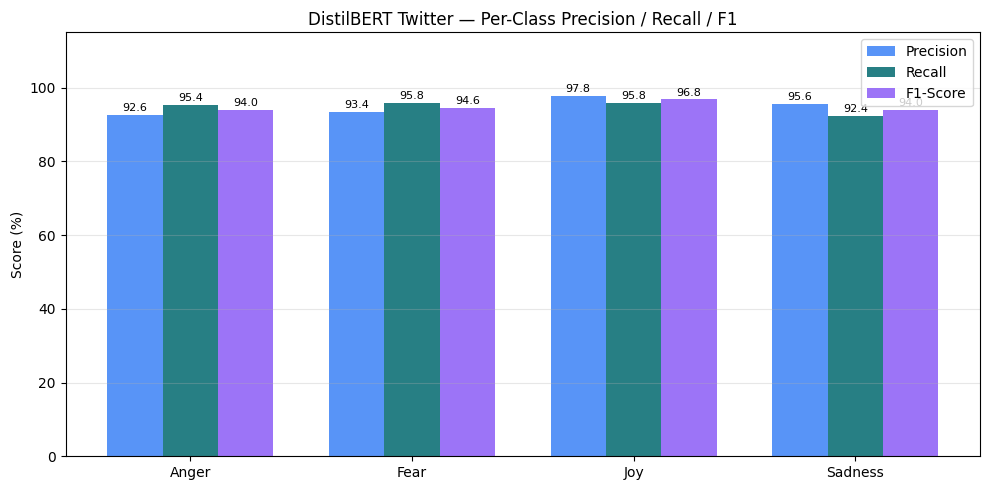

Saved: distilbert_twitter_perclass.png


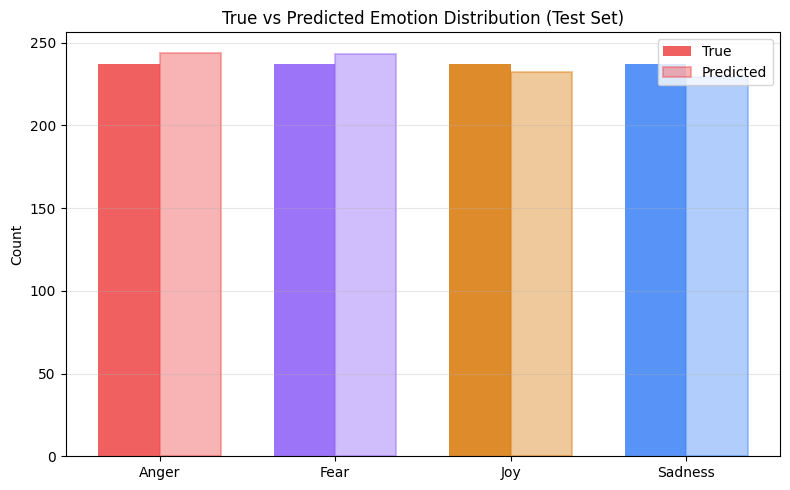

Saved: distilbert_twitter_dist.png

MODEL 2 DONE  |  Test Accuracy: 94.83%
Saved to: /kaggle/working/distilbert_twitter


In [6]:
# DistilBERT Twitter      


import pandas as pd, numpy as np, torch, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

WD     = "/kaggle/working"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 128
BATCH_SIZE  = 64
EPOCHS      = 4
LR          = 3e-5
EMO2ID      = {"anger": 0, "fear": 1, "joy": 2, "sadness": 3}
ID2EMO      = {0: "anger", 1: "fear", 2: "joy", 3: "sadness"}
EMO_NAMES   = ["anger", "fear", "joy", "sadness"]
# dair-ai/emotion label indices: 0=sadness,1=joy,2=love,3=anger,4=fear,5=surprise
DAIR_MAP    = {0: "sadness", 1: "joy", 3: "anger", 4: "fear"}  # keep only our 4
SAVE_PATH   = f"{WD}/distilbert_twitter"

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

# ── LOAD dair-ai/emotion (real Twitter emotion labels) ───────
print("Loading dair-ai/emotion from HuggingFace...")
raw = load_dataset("dair-ai/emotion", split="train+validation+test")
df_raw = raw.to_pandas()
print("Raw label distribution:", df_raw["label"].value_counts().to_dict())

# Filter to our 4 emotions and remap
df_raw = df_raw[df_raw["label"].isin(DAIR_MAP.keys())].copy()
df_raw["emotion"] = df_raw["label"].map(DAIR_MAP)
df_raw = df_raw[["text", "emotion"]].dropna()
df_raw["text"] = df_raw["text"].str.strip()
df_raw = df_raw[df_raw["text"].str.split().str.len() >= 3]
df_raw = df_raw.drop_duplicates(subset="text").reset_index(drop=True)

# Balance to min class count
print("Before balance:", df_raw["emotion"].value_counts().to_dict())
mn = df_raw["emotion"].value_counts().min()
balanced = []
for emo in EMO_NAMES:
    balanced.append(df_raw[df_raw["emotion"] == emo].sample(n=mn, random_state=SEED))
df = pd.concat(balanced).sample(frac=1, random_state=SEED).reset_index(drop=True)
print("After balance:", df["emotion"].value_counts().to_dict())
print(f"Total: {len(df):,}")

# Save cleaned Twitter emotion file
df["label_id"] = df["emotion"].map(EMO2ID)
df.to_csv(f"{WD}/cleaned_twitter_emotion.csv", index=False)
print("Saved: cleaned_twitter_emotion.csv (real labels)")

# ── SPLIT ────────────────────────────────────────────────────
X, y = df["text"], df["label_id"]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te  = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
print(f"Train: {len(X_tr):,}  Val: {len(X_val):,}  Test: {len(X_te):,}")

# ── TOKENIZER + LOADERS ──────────────────────────────────────
tok      = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dl = DataLoader(EmotionDataset(X_tr,  y_tr,  tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(EmotionDataset(X_val, y_val, tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(EmotionDataset(X_te,  y_te,  tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── MODEL ────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4)
model.config.id2label = ID2EMO
model.config.label2id = EMO2ID
model = model.to(DEVICE)

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer,
    num_warmup_steps=total_steps//10, num_training_steps=total_steps)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["labels"].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            if training:
                optimizer.zero_grad(); out.loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            preds       = out.logits.argmax(dim=1)
            total_loss += out.loss.item() * lbls.size(0)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total

print("\n" + "="*60)
print("TRAINING DistilBERT — TWITTER EMOTION (dair-ai/emotion)")
print("="*60)
best_val_acc, best_epoch = 0, 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc   = run_epoch(train_dl, training=True)
    val_loss, val_acc = run_epoch(val_dl,   training=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | Time: {time.time()-t0:.0f}s")
    if val_acc > best_val_acc:
        best_val_acc = val_acc; best_epoch = epoch
        model.save_pretrained(SAVE_PATH); tok.save_pretrained(SAVE_PATH)
        print(f"  ✅ Best model saved (val_acc={val_acc:.4f})")

print(f"\nBest Epoch: {best_epoch}  |  Best Val Acc: {best_val_acc:.4f}")

# ── TEST EVALUATION ──────────────────────────────────────────
print("\nEvaluating on test set...")
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_dl:
        out = model(input_ids=batch["input_ids"].to(DEVICE),
                    attention_mask=batch["attention_mask"].to(DEVICE))
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

test_acc = accuracy_score(all_true, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=EMO_NAMES, digits=4))

# ── PLOT 1: Loss + Accuracy + Confusion Matrix ───────────────
EMO_COLORS = {"anger":"#ef4444","fear":"#8b5cf6","joy":"#d97706","sadness":"#3b82f6"}
epochs_x   = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DistilBERT — Twitter Emotion Detection (dair-ai/emotion)", fontsize=14, fontweight="bold")

axes[0].plot(epochs_x, history["train_loss"], "o-", color="#01696f", label="Train", lw=2)
axes[0].plot(epochs_x, history["val_loss"],   "s--",color="#ef4444", label="Val",   lw=2)
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(epochs_x)

axes[1].plot(epochs_x, [a*100 for a in history["train_acc"]], "o-", color="#01696f", label="Train", lw=2)
axes[1].plot(epochs_x, [a*100 for a in history["val_acc"]],   "s--",color="#ef4444", label="Val",   lw=2)
axes[1].axhline(test_acc*100, color="#8b5cf6", ls=":", lw=1.5, label=f"Test {test_acc*100:.1f}%")
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xticks(epochs_x)

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=EMO_NAMES, yticklabels=EMO_NAMES,
            ax=axes[2], linewidths=0.5)
axes[2].set_title("Confusion Matrix (Test)"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_twitter_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distilbert_twitter_results.png")

# ── PLOT 2: Per-Class Precision / Recall / F1 ────────────────
prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, labels=[0,1,2,3])
fig2, ax2 = plt.subplots(figsize=(10, 5))
x = np.arange(4); w = 0.25
b1 = ax2.bar(x-w, prec*100, w, label="Precision", color="#3b82f6", alpha=0.85)
b2 = ax2.bar(x,   rec*100,  w, label="Recall",    color="#01696f", alpha=0.85)
b3 = ax2.bar(x+w, f1*100,   w, label="F1-Score",  color="#8b5cf6", alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels([e.capitalize() for e in EMO_NAMES])
ax2.set_ylim(0, 115); ax2.set_ylabel("Score (%)")
ax2.set_title("DistilBERT Twitter — Per-Class Precision / Recall / F1")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_twitter_perclass.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distilbert_twitter_perclass.png")

# ── PLOT 3: True vs Predicted Distribution ───────────────────
pred_counts = pd.Series([ID2EMO[p] for p in all_preds]).value_counts()
true_counts = pd.Series([ID2EMO[t] for t in all_true]).value_counts()
fig3, ax3 = plt.subplots(figsize=(8, 5))
x = np.arange(len(EMO_NAMES)); w = 0.35
ax3.bar(x-w/2, [true_counts.get(e,0) for e in EMO_NAMES], w,
        label="True",      color=[EMO_COLORS[e] for e in EMO_NAMES], alpha=0.85)
ax3.bar(x+w/2, [pred_counts.get(e,0) for e in EMO_NAMES], w,
        label="Predicted", color=[EMO_COLORS[e] for e in EMO_NAMES], alpha=0.4,
        edgecolor=[EMO_COLORS[e] for e in EMO_NAMES], linewidth=1.5)
ax3.set_xticks(x); ax3.set_xticklabels([e.capitalize() for e in EMO_NAMES])
ax3.set_ylabel("Count"); ax3.set_title("True vs Predicted Emotion Distribution (Test Set)")
ax3.legend(); ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_twitter_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distilbert_twitter_dist.png")

print("\n" + "="*60)
print(f"MODEL 2 DONE  |  Test Accuracy: {test_acc*100:.2f}%")
print(f"Saved to: {SAVE_PATH}")
print("="*60)


Loading FULL go_emotions (unbalanced)...
Full distribution: {'joy': 24783, 'sadness': 10162, 'anger': 7923, 'fear': 1872}
Total: 44,740

Train: 42,340 (unbalanced) | Val: 1,200 (balanced) | Test: 1,200 (balanced)
Train dist: {'joy': 24183, 'sadness': 9562, 'anger': 7323, 'fear': 1272}
Val dist  : {'sadness': 300, 'joy': 300, 'anger': 300, 'fear': 300}
Test dist : {'sadness': 300, 'joy': 300, 'anger': 300, 'fear': 300}
Class weights: {'anger': 1.445, 'fear': 8.322, 'joy': 0.438, 'sadness': 1.107}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TRAINING DistilBERT — REDDIT EMOTION (FINAL)
Train=full unbalanced | Val+Test=balanced 300/class
Epoch 1/6 | Train Loss: 1.1008  Acc: 0.6036 | Val Loss: 0.8130  Acc: 0.6308 | Time: 219s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.6308)
Epoch 2/6 | Train Loss: 0.8594  Acc: 0.7240 | Val Loss: 1.1393  Acc: 0.6425 | Time: 218s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.6425)
Epoch 3/6 | Train Loss: 0.6841  Acc: 0.7726 | Val Loss: 1.5083  Acc: 0.6383 | Time: 218s
  ⏳ No improvement (1/2)
Epoch 4/6 | Train Loss: 0.5192  Acc: 0.8172 | Val Loss: 1.9014  Acc: 0.6350 | Time: 218s
  ⏳ No improvement (2/2)
  🛑 Early stopping!

Best Epoch: 2  |  Best Val Acc: 0.6425

Evaluating on BALANCED test set...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Test Accuracy: 0.6325  (balanced test set — metric is valid)
              precision    recall  f1-score   support

       anger     0.5425    0.5533    0.5479       300
        fear     0.7574    0.5100    0.6096       300
         joy     0.7214    0.8200    0.7676       300
     sadness     0.5527    0.6467    0.5960       300

    accuracy                         0.6325      1200
   macro avg     0.6435    0.6325    0.6302      1200
weighted avg     0.6435    0.6325    0.6302      1200



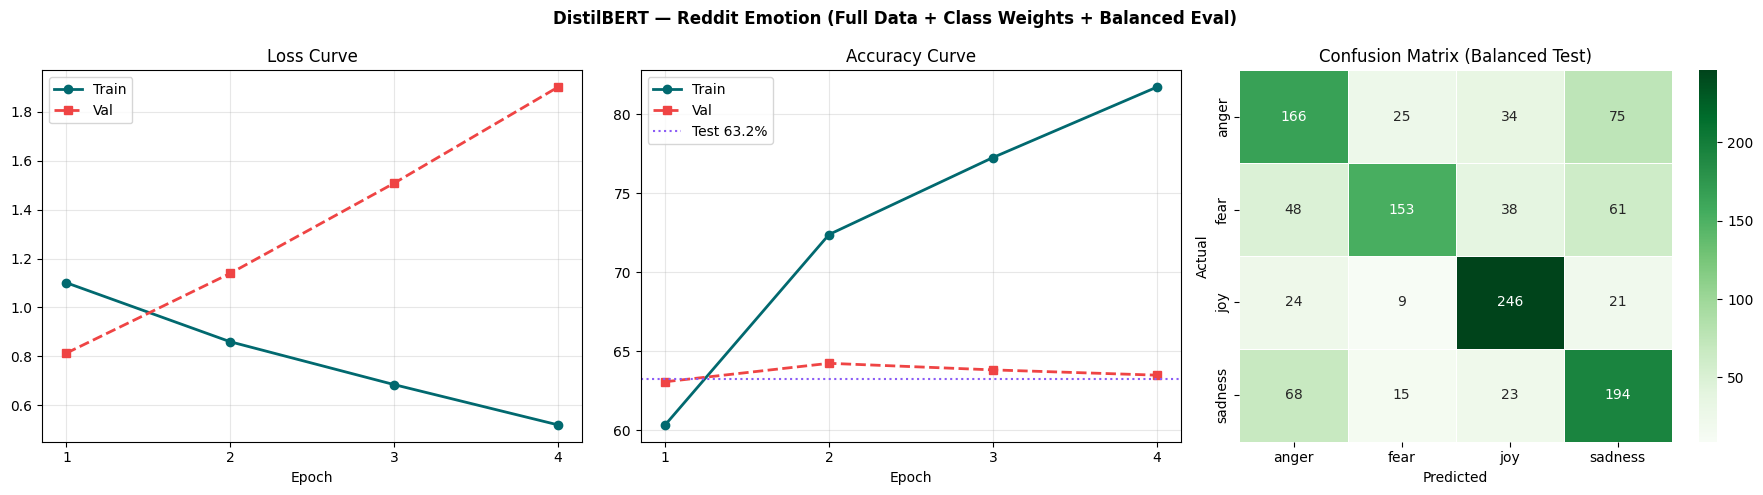

Saved: distilbert_reddit_results.png


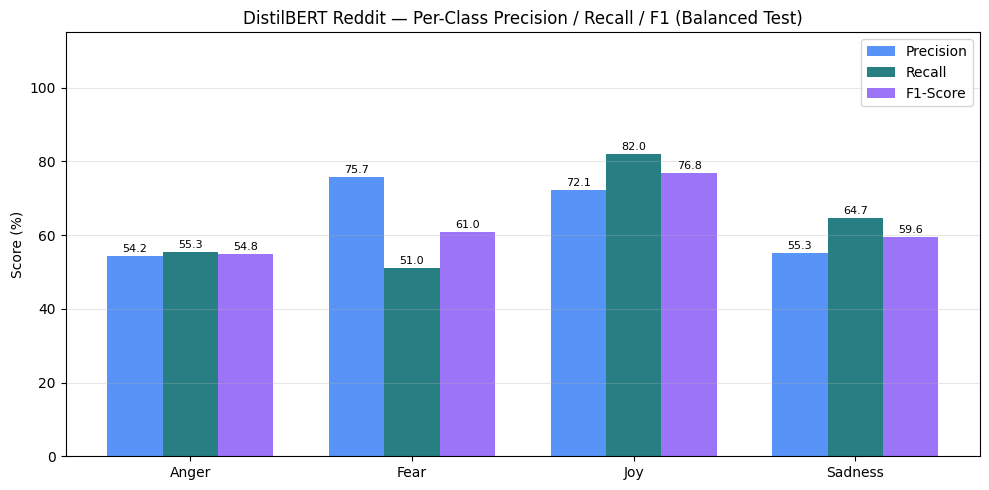

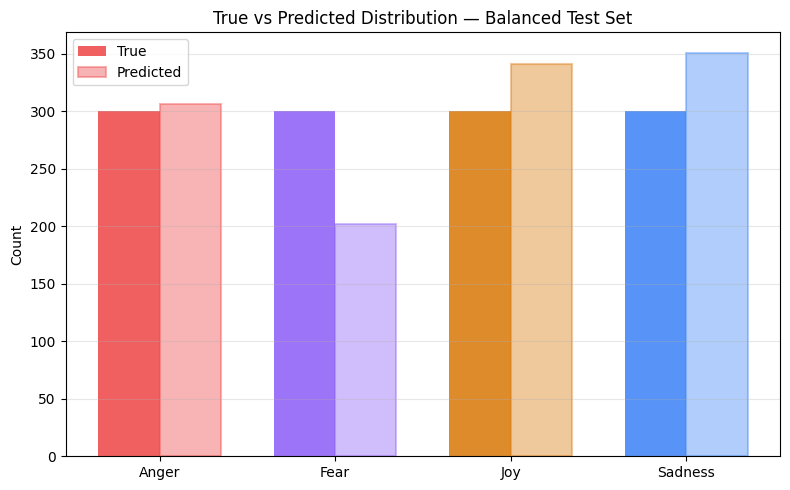


MODEL 3 FINAL  |  Test Accuracy: 63.25%
Balanced test set — accuracy is fully valid ✅
Saved to: /kaggle/working/distilbert_reddit


In [7]:
# DistilBERT Reddit      

import pandas as pd, numpy as np, torch, time, warnings, re
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

WD     = "/kaggle/working"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 64
BATCH_SIZE  = 64
EPOCHS      = 6
LR          = 3e-5
PATIENCE    = 2
EMO2ID      = {"anger": 0, "fear": 1, "joy": 2, "sadness": 3}
ID2EMO      = {0: "anger", 1: "fear", 2: "joy", 3: "sadness"}
EMO_NAMES   = ["anger", "fear", "joy", "sadness"]
EMO_COLORS  = {"anger":"#ef4444","fear":"#8b5cf6","joy":"#d97706","sadness":"#3b82f6"}
SAVE_PATH   = f"{WD}/distilbert_reddit"
GO_PATH     = "/kaggle/input/datasets/ganeshbanotu/social-media/go_emotions_dataset.csv"

GROUPED = {
    "joy":     ["joy","amusement","excitement","gratitude","admiration",
                "optimism","love","relief","pride","caring"],
    "sadness": ["sadness","grief","remorse","disappointment","disapproval"],
    "anger":   ["anger","annoyance","disgust"],
    "fear":    ["fear","nervousness","embarrassment"],
}

def clean(text):
    if not isinstance(text, str): return None
    text = re.sub(r"http\S+|@\w+|#(\w+)", r"\1", text)
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text.split()) >= 3 else None

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

# ── LOAD FULL go_emotions ─────────────────────────────────────
print("Loading FULL go_emotions (unbalanced)...")
go = pd.read_csv(GO_PATH, on_bad_lines="skip")
go = go[go["example_very_unclear"] == False].copy()

def get_emotion(row):
    for emo, cols in GROUPED.items():
        for col in cols:
            if col in row.index and row[col] == 1:
                return emo
    return None

go["emotion"] = go.apply(get_emotion, axis=1)
go.dropna(subset=["emotion"], inplace=True)
go["text"]    = go["text"].apply(clean)
go.dropna(subset=["text"], inplace=True)
go = go[["text","emotion"]].drop_duplicates(subset="text").reset_index(drop=True)
go["label_id"] = go["emotion"].map(EMO2ID).astype(int)
print("Full distribution:", go["emotion"].value_counts().to_dict())
print(f"Total: {len(go):,}")

# ── BALANCED VAL + TEST, UNBALANCED TRAIN ────────────────────
# Step 1: Carve out balanced val+test first (300/class each)
PER_CLASS_EVAL = min(300, go["label_id"].value_counts().min() // 2)
val_parts, test_parts, train_parts = [], [], []
for lbl in range(4):
    subset = go[go["label_id"] == lbl].sample(frac=1, random_state=SEED).reset_index(drop=True)
    val_parts.append(subset.iloc[:PER_CLASS_EVAL])
    test_parts.append(subset.iloc[PER_CLASS_EVAL:PER_CLASS_EVAL*2])
    train_parts.append(subset.iloc[PER_CLASS_EVAL*2:])   # all remaining → train

val_df   = pd.concat(val_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df  = pd.concat(test_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
train_df = pd.concat(train_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nTrain: {len(train_df):,} (unbalanced) | Val: {len(val_df):,} (balanced) | Test: {len(test_df):,} (balanced)")
print("Train dist:", train_df["emotion"].value_counts().to_dict())
print("Val dist  :", val_df["emotion"].value_counts().to_dict())
print("Test dist :", test_df["emotion"].value_counts().to_dict())

# ── CLASS WEIGHTS (based on train distribution) ──────────────
counts  = train_df["label_id"].value_counts().sort_index()
weights = torch.tensor(
    [len(train_df) / (4 * counts[i]) for i in range(4)],
    dtype=torch.float).to(DEVICE)
print("Class weights:", {ID2EMO[i]: round(w.item(),3) for i,w in enumerate(weights)})

tok      = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dl = DataLoader(EmotionDataset(train_df["text"], train_df["label_id"], tok, MAX_LEN),
                      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(EmotionDataset(val_df["text"],   val_df["label_id"],   tok, MAX_LEN),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(EmotionDataset(test_df["text"],  test_df["label_id"],  tok, MAX_LEN),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4)
model.config.id2label = ID2EMO; model.config.label2id = EMO2ID
model = model.to(DEVICE)

loss_fn     = torch.nn.CrossEntropyLoss(weight=weights)
optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer,
    num_warmup_steps=int(total_steps*0.15), num_training_steps=total_steps)

history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["labels"].to(DEVICE)
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss   = loss_fn(logits, lbls)
            if training:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            preds       = logits.argmax(dim=1)
            total_loss += loss.item() * lbls.size(0)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total

print("\n" + "="*60)
print("TRAINING DistilBERT — REDDIT EMOTION (FINAL)")
print("Train=full unbalanced | Val+Test=balanced 300/class")
print("="*60)
best_val_acc, best_epoch, patience_ctr = 0, 0, 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc   = run_epoch(train_dl, True)
    val_loss, val_acc = run_epoch(val_dl,   False)
    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | Time: {time.time()-t0:.0f}s")
    if val_acc > best_val_acc:
        best_val_acc = val_acc; best_epoch = epoch; patience_ctr = 0
        model.save_pretrained(SAVE_PATH); tok.save_pretrained(SAVE_PATH)
        print(f"  ✅ Best model saved (val_acc={val_acc:.4f})")
    else:
        patience_ctr += 1
        print(f"  ⏳ No improvement ({patience_ctr}/{PATIENCE})")
        if patience_ctr >= PATIENCE:
            print("  🛑 Early stopping!"); break

print(f"\nBest Epoch: {best_epoch}  |  Best Val Acc: {best_val_acc:.4f}")

print("\nEvaluating on BALANCED test set...")
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_dl:
        out = model(input_ids=batch["input_ids"].to(DEVICE),
                    attention_mask=batch["attention_mask"].to(DEVICE))
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

test_acc = accuracy_score(all_true, all_preds)
print(f"Test Accuracy: {test_acc:.4f}  (balanced test set — metric is valid)")
print(classification_report(all_true, all_preds, target_names=EMO_NAMES, digits=4))

# PLOTS
epochs_x = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DistilBERT — Reddit Emotion (Full Data + Class Weights + Balanced Eval)", fontsize=12, fontweight="bold")
axes[0].plot(epochs_x, history["train_loss"], "o-", color="#01696f", label="Train", lw=2)
axes[0].plot(epochs_x, history["val_loss"],   "s--",color="#ef4444", label="Val",   lw=2)
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(epochs_x)
axes[1].plot(epochs_x, [a*100 for a in history["train_acc"]], "o-", color="#01696f", label="Train", lw=2)
axes[1].plot(epochs_x, [a*100 for a in history["val_acc"]],   "s--",color="#ef4444", label="Val",   lw=2)
axes[1].axhline(test_acc*100, color="#8b5cf6", ls=":", lw=1.5, label=f"Test {test_acc*100:.1f}%")
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xticks(epochs_x)
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=EMO_NAMES, yticklabels=EMO_NAMES, ax=axes[2], linewidths=0.5)
axes[2].set_title("Confusion Matrix (Balanced Test)"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_reddit_results.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: distilbert_reddit_results.png")

prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, labels=[0,1,2,3])
fig2, ax2 = plt.subplots(figsize=(10, 5))
x = np.arange(4); w = 0.25
b1 = ax2.bar(x-w, prec*100, w, label="Precision", color="#3b82f6", alpha=0.85)
b2 = ax2.bar(x,   rec*100,  w, label="Recall",    color="#01696f", alpha=0.85)
b3 = ax2.bar(x+w, f1*100,   w, label="F1-Score",  color="#8b5cf6", alpha=0.85)
for bars in [b1,b2,b3]:
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels([e.capitalize() for e in EMO_NAMES])
ax2.set_ylim(0,115); ax2.legend(); ax2.grid(axis="y", alpha=0.3)
ax2.set_title("DistilBERT Reddit — Per-Class Precision / Recall / F1 (Balanced Test)")
ax2.set_ylabel("Score (%)")
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_reddit_perclass.png", dpi=150, bbox_inches="tight")
plt.show()

pred_counts = pd.Series([ID2EMO[p] for p in all_preds]).value_counts()
true_counts = pd.Series([ID2EMO[t] for t in all_true]).value_counts()
fig3, ax3 = plt.subplots(figsize=(8, 5))
xx = np.arange(len(EMO_NAMES)); ww = 0.35
ax3.bar(xx-ww/2, [true_counts.get(e,0) for e in EMO_NAMES], ww, label="True",
        color=[EMO_COLORS[e] for e in EMO_NAMES], alpha=0.85)
ax3.bar(xx+ww/2, [pred_counts.get(e,0) for e in EMO_NAMES], ww, label="Predicted",
        color=[EMO_COLORS[e] for e in EMO_NAMES], alpha=0.4,
        edgecolor=[EMO_COLORS[e] for e in EMO_NAMES], linewidth=1.5)
ax3.set_xticks(xx); ax3.set_xticklabels([e.capitalize() for e in EMO_NAMES])
ax3.set_ylabel("Count"); ax3.legend(); ax3.grid(axis="y", alpha=0.3)
ax3.set_title("True vs Predicted Distribution — Balanced Test Set")
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_reddit_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*60}")
print(f"MODEL 3 FINAL  |  Test Accuracy: {test_acc*100:.2f}%")
print(f"Balanced test set — accuracy is fully valid ✅")
print(f"Saved to: {SAVE_PATH}")
print(f"{'='*60}")

Loading cleaned_isear.csv...
Label dist: {'fear': 1388, 'joy': 1388, 'anger': 1388, 'sadness': 1388}
Train: 4,441  Val: 555  Test: 556


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TRAINING DistilBERT — LINKEDIN EMOTION
Epoch 1/5 | Train Loss: 1.2365  Acc: 0.4364 | Val Loss: 0.7677  Acc: 0.7514 | Time: 48s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✅ Best model saved (val_acc=0.8775)
Epoch 3/5 | Train Loss: 0.2653  Acc: 0.9174 | Val Loss: 0.3328  Acc: 0.9045 | Time: 48s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Best model saved (val_acc=0.9045)
Epoch 4/5 | Train Loss: 0.1795  Acc: 0.9484 | Val Loss: 0.3449  Acc: 0.8973 | Time: 47s
Epoch 5/5 | Train Loss: 0.1334  Acc: 0.9626 | Val Loss: 0.3482  Acc: 0.9009 | Time: 48s

Best Epoch: 3  |  Best Val Acc: 0.9045

Evaluating on test set...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Test Accuracy: 0.8543

Classification Report:
              precision    recall  f1-score   support

       anger     0.8112    0.8345    0.8227       139
        fear     0.8309    0.8129    0.8218       139
         joy     0.8889    0.9209    0.9046       139
     sadness     0.8872    0.8489    0.8676       139

    accuracy                         0.8543       556
   macro avg     0.8545    0.8543    0.8542       556
weighted avg     0.8545    0.8543    0.8542       556



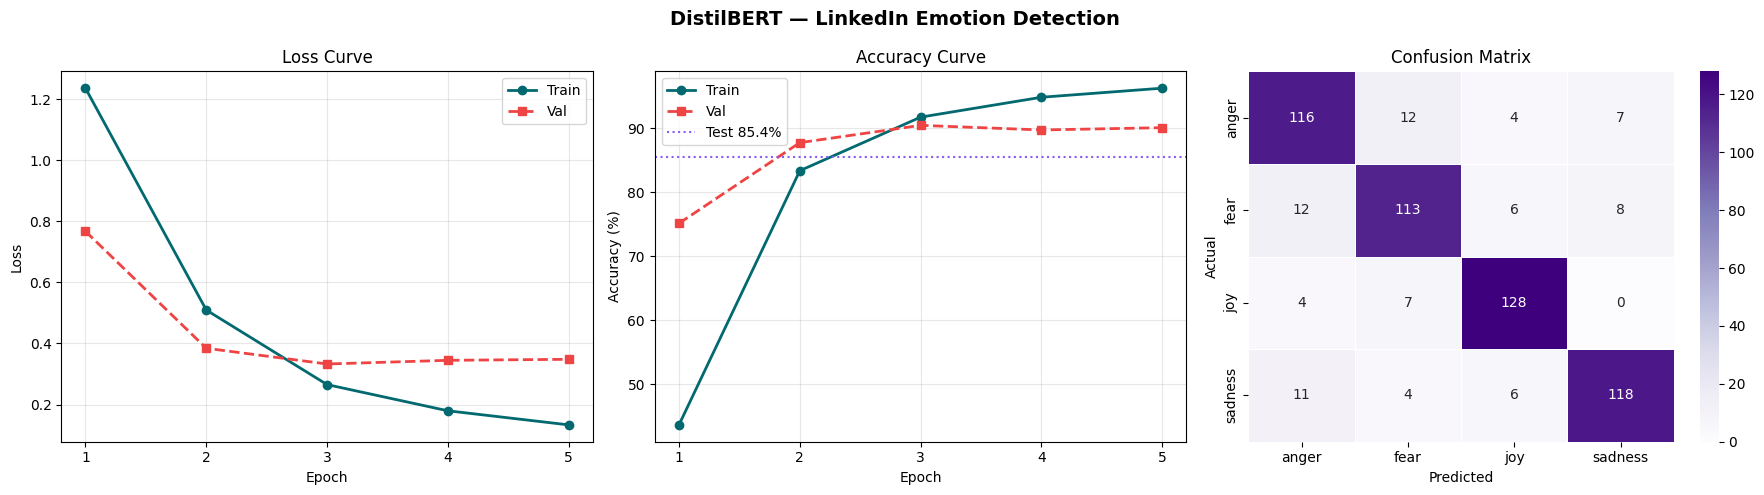

Saved: distilbert_linkedin_results.png


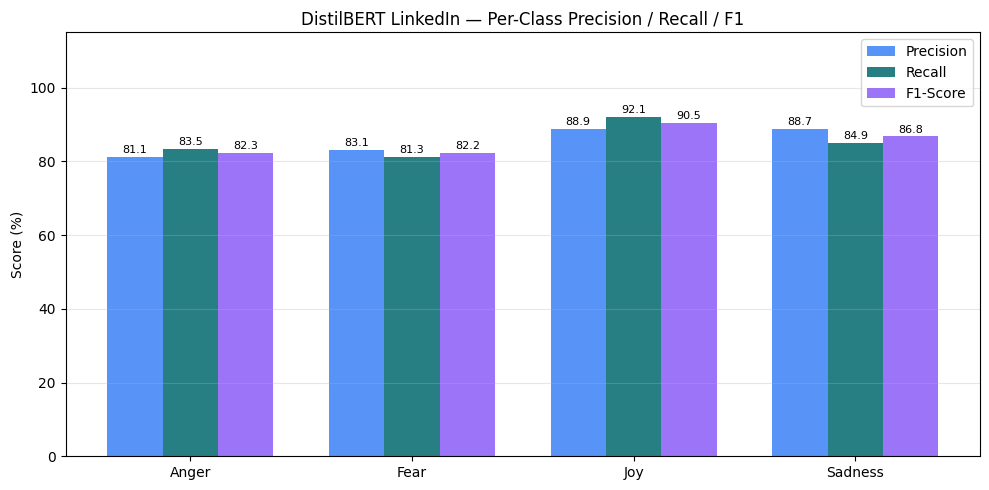

Saved: distilbert_linkedin_perclass.png


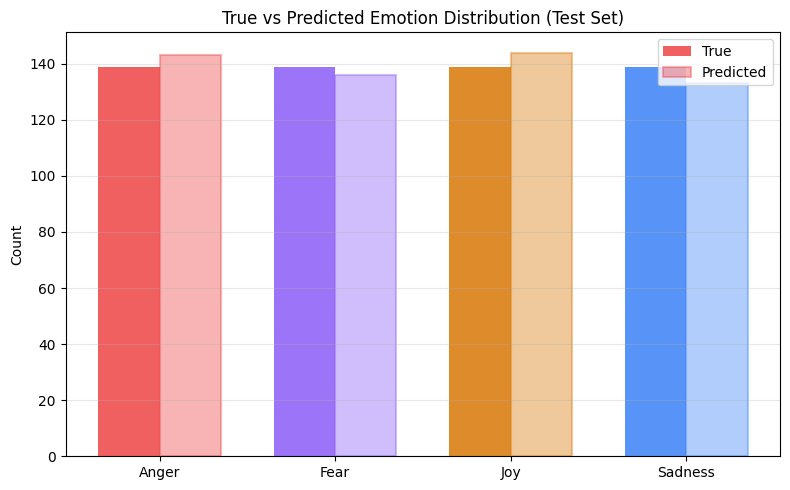

Saved: distilbert_linkedin_dist.png

MODEL 4 DONE  |  Test Accuracy: 85.43%
Saved to: /kaggle/working/distilbert_linkedin

🎉 ALL 4 MODELS TRAINED!


In [8]:
# DistilBERT LinkedIn Emotion        


import pandas as pd, numpy as np, torch, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

WD     = "/kaggle/working"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 128
BATCH_SIZE  = 64
EPOCHS      = 5
LR          = 3e-5
EMO2ID      = {"anger": 0, "fear": 1, "joy": 2, "sadness": 3}
ID2EMO      = {0: "anger", 1: "fear", 2: "joy", 3: "sadness"}
EMO_NAMES   = ["anger", "fear", "joy", "sadness"]
EMO_COLORS  = {"anger":"#ef4444","fear":"#8b5cf6","joy":"#d97706","sadness":"#3b82f6"}
SAVE_PATH   = f"{WD}/distilbert_linkedin"

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

print("Loading cleaned_isear.csv...")
df = pd.read_csv(f"{WD}/cleaned_isear.csv")
df["label_id"] = df["emotion"].map(EMO2ID).astype(int)
print("Label dist:", df["emotion"].value_counts().to_dict())

X, y = df["text"], df["label_id"]
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te  = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
print(f"Train: {len(X_tr):,}  Val: {len(X_val):,}  Test: {len(X_te):,}")

tok      = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dl = DataLoader(EmotionDataset(X_tr,  y_tr,  tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(EmotionDataset(X_val, y_val, tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(EmotionDataset(X_te,  y_te,  tok, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4)
model.config.id2label = ID2EMO; model.config.label2id = EMO2ID
model = model.to(DEVICE)

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer,
    num_warmup_steps=total_steps//10, num_training_steps=total_steps)

history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["labels"].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            if training:
                optimizer.zero_grad(); out.loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            preds       = out.logits.argmax(dim=1)
            total_loss += out.loss.item() * lbls.size(0)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total

print("\n" + "="*60)
print("TRAINING DistilBERT — LINKEDIN EMOTION")
print("="*60)
best_val_acc, best_epoch = 0, 0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc   = run_epoch(train_dl, True)
    val_loss, val_acc = run_epoch(val_dl,   False)
    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | Time: {time.time()-t0:.0f}s")
    if val_acc > best_val_acc:
        best_val_acc = val_acc; best_epoch = epoch
        model.save_pretrained(SAVE_PATH); tok.save_pretrained(SAVE_PATH)
        print(f"  ✅ Best model saved (val_acc={val_acc:.4f})")

print(f"\nBest Epoch: {best_epoch}  |  Best Val Acc: {best_val_acc:.4f}")

print("\nEvaluating on test set...")
model = AutoModelForSequenceClassification.from_pretrained(SAVE_PATH).to(DEVICE)
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_dl:
        out = model(input_ids=batch["input_ids"].to(DEVICE), attention_mask=batch["attention_mask"].to(DEVICE))
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

test_acc = accuracy_score(all_true, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=EMO_NAMES, digits=4))

# PLOTS
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DistilBERT — LinkedIn Emotion Detection", fontsize=14, fontweight="bold")
axes[0].plot(epochs_x, history["train_loss"], "o-", color="#01696f", label="Train", lw=2)
axes[0].plot(epochs_x, history["val_loss"],   "s--",color="#ef4444", label="Val",   lw=2)
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(epochs_x)

axes[1].plot(epochs_x, [a*100 for a in history["train_acc"]], "o-", color="#01696f", label="Train", lw=2)
axes[1].plot(epochs_x, [a*100 for a in history["val_acc"]],   "s--",color="#ef4444", label="Val",   lw=2)
axes[1].axhline(test_acc*100, color="#8b5cf6", ls=":", lw=1.5, label=f"Test {test_acc*100:.1f}%")
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xticks(epochs_x)

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=EMO_NAMES, yticklabels=EMO_NAMES, ax=axes[2], linewidths=0.5)
axes[2].set_title("Confusion Matrix"); axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_linkedin_results.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: distilbert_linkedin_results.png")

prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, labels=[0,1,2,3])
fig2, ax2 = plt.subplots(figsize=(10, 5))
x = np.arange(4); w = 0.25
b1 = ax2.bar(x-w, prec*100, w, label="Precision", color="#3b82f6", alpha=0.85)
b2 = ax2.bar(x,   rec*100,  w, label="Recall",    color="#01696f", alpha=0.85)
b3 = ax2.bar(x+w, f1*100,   w, label="F1-Score",  color="#8b5cf6", alpha=0.85)
for bars in [b1,b2,b3]:
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels([e.capitalize() for e in EMO_NAMES])
ax2.set_ylim(0,115); ax2.set_ylabel("Score (%)")
ax2.set_title("DistilBERT LinkedIn — Per-Class Precision / Recall / F1")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_linkedin_perclass.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: distilbert_linkedin_perclass.png")

pred_counts = pd.Series([ID2EMO[p] for p in all_preds]).value_counts()
true_counts = pd.Series([ID2EMO[t] for t in all_true]).value_counts()
fig3, ax3 = plt.subplots(figsize=(8, 5))
x = np.arange(len(EMO_NAMES)); w = 0.35
ax3.bar(x-w/2, [true_counts.get(e,0) for e in EMO_NAMES], w, label="True",
        color=[EMO_COLORS[e] for e in EMO_NAMES], alpha=0.85)
ax3.bar(x+w/2, [pred_counts.get(e,0) for e in EMO_NAMES], w, label="Predicted",
        color=[EMO_COLORS[e] for e in EMO_NAMES], alpha=0.4,
        edgecolor=[EMO_COLORS[e] for e in EMO_NAMES], linewidth=1.5)
ax3.set_xticks(x); ax3.set_xticklabels([e.capitalize() for e in EMO_NAMES])
ax3.set_ylabel("Count"); ax3.set_title("True vs Predicted Emotion Distribution (Test Set)")
ax3.legend(); ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{WD}/distilbert_linkedin_dist.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: distilbert_linkedin_dist.png")

print("\n" + "="*60)
print(f"MODEL 4 DONE  |  Test Accuracy: {test_acc*100:.2f}%")
print(f"Saved to: {SAVE_PATH}")
print("="*60)
print("\n🎉 ALL 4 MODELS TRAINED!")


Saved: model_summary.csv
              Short       Platform  Accuracy  F1_Macro  Classes
      RoBERTa-Broad Cross-Platform     77.07     76.89        3
 DistilBERT-Twitter        Twitter     94.83     94.84        4
  DistilBERT-Reddit         Reddit     63.25     63.02        4
DistilBERT-LinkedIn       LinkedIn     85.43     85.42        4


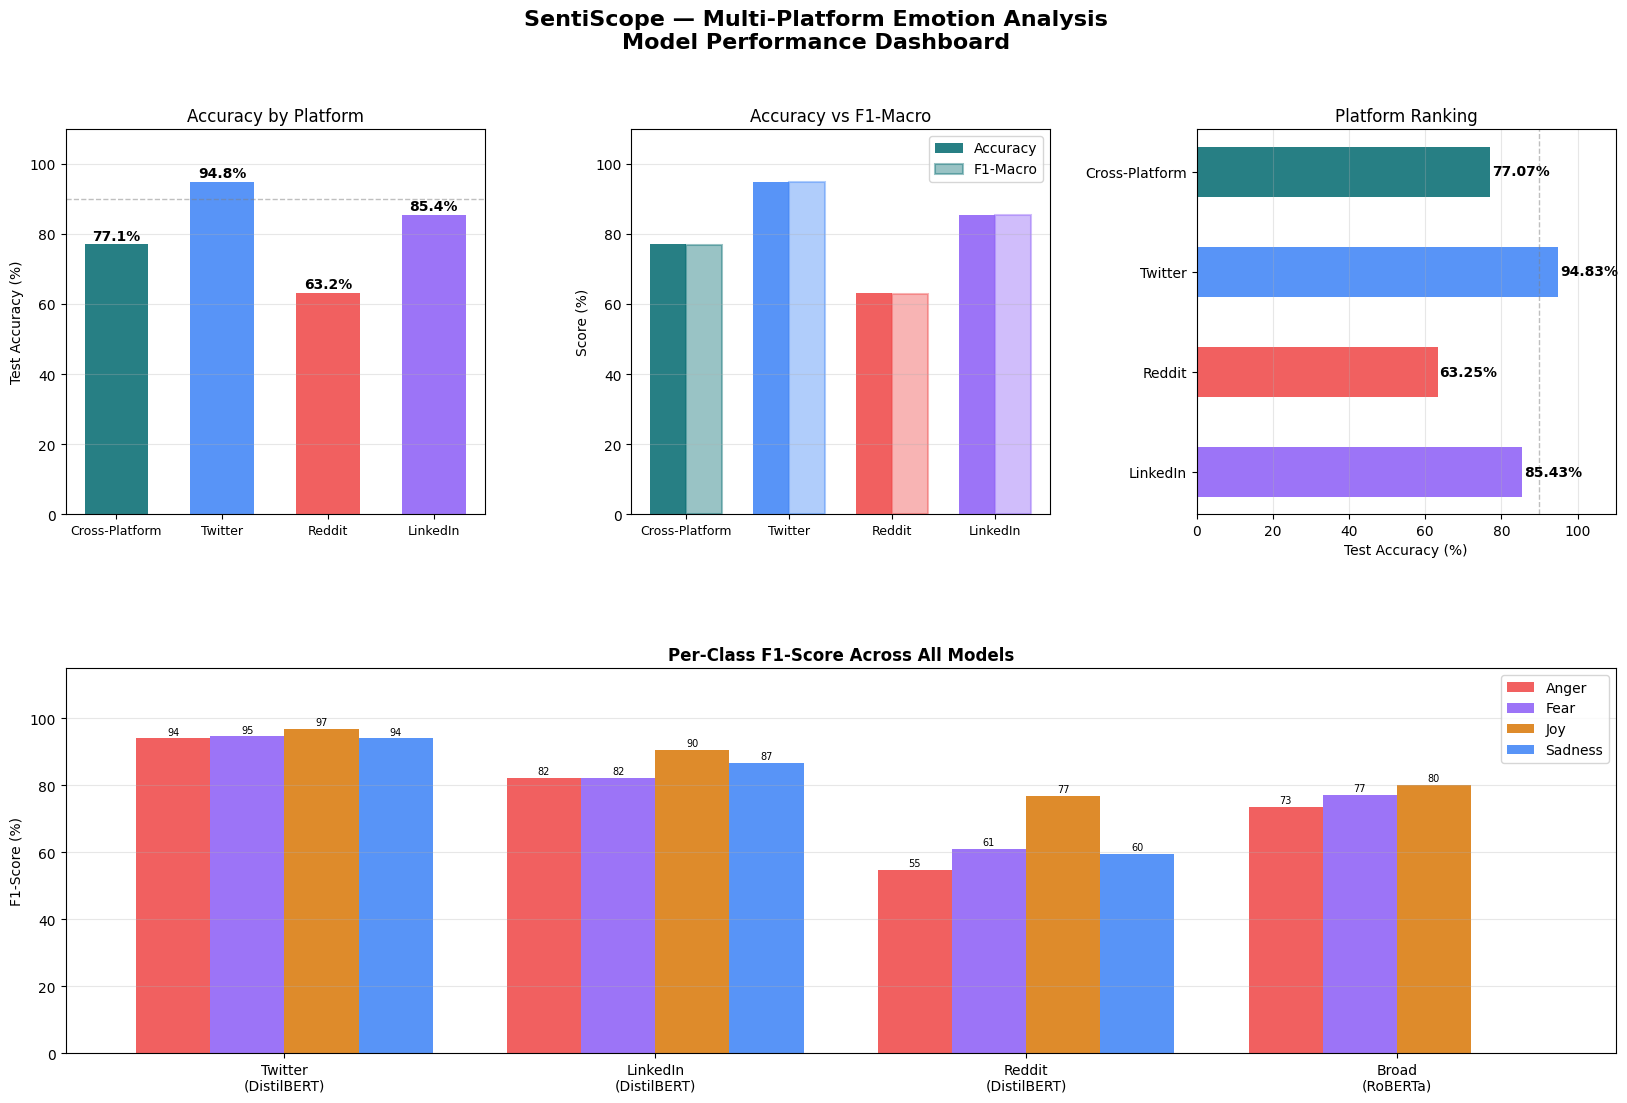

Saved: sentiscope_dashboard.png


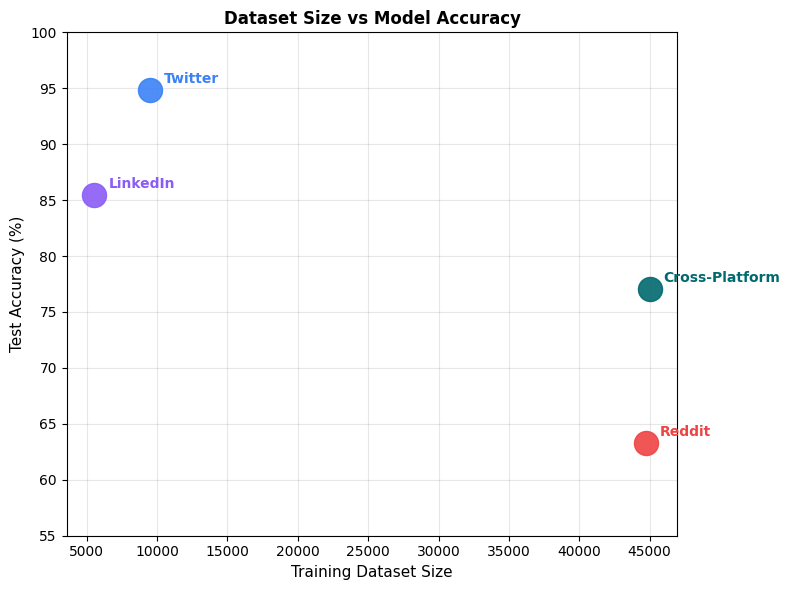

Saved: sentiscope_size_vs_acc.png

UPLOADING TO HUGGINGFACE HUB
✅ Token loaded from Kaggle Secrets
✅ HuggingFace login successful

Uploading roberta_broad → Ganesh1912/sentiscope-roberta-broad ...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


  ✅ https://huggingface.co/Ganesh1912/sentiscope-roberta-broad

Uploading distilbert_twitter → Ganesh1912/sentiscope-distilbert-twitter ...


...

  ✅ https://huggingface.co/Ganesh1912/sentiscope-distilbert-reddit

Uploading distilbert_linkedin → Ganesh1912/sentiscope-distilbert-linkedin ...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


  ✅ https://huggingface.co/Ganesh1912/sentiscope-distilbert-linkedin

COPY THESE INTO CELL 10 (Streamlit App)
  sentiscope-roberta-broad                 → https://huggingface.co/Ganesh1912/sentiscope-roberta-broad
  sentiscope-distilbert-twitter            → https://huggingface.co/Ganesh1912/sentiscope-distilbert-twitter
  sentiscope-distilbert-reddit             → https://huggingface.co/Ganesh1912/sentiscope-distilbert-reddit
  sentiscope-distilbert-linkedin           → https://huggingface.co/Ganesh1912/sentiscope-distilbert-linkedin

MODEL_REGISTRY = {
    "Twitter":  "Ganesh1912/sentiscope-distilbert-twitter",
    "Reddit":   "Ganesh1912/sentiscope-distilbert-reddit",
    "LinkedIn": "Ganesh1912/sentiscope-distilbert-linkedin",
    "Broad":    "Ganesh1912/sentiscope-roberta-broad",
}



In [9]:
# Comparison Dashboard + HF Upload   


import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from huggingface_hub import HfApi, login
from kaggle_secrets import UserSecretsClient
import subprocess, warnings
warnings.filterwarnings("ignore")

subprocess.run(["pip", "install", "-q", "huggingface_hub"], check=True)

WD = "/kaggle/working"

# ── FINAL RESULTS ─────────────────────────────────────────────
results = {
    "Model":     ["RoBERTa\nBroad Sentiment", "DistilBERT\nTwitter",
                  "DistilBERT\nReddit",        "DistilBERT\nLinkedIn"],
    "Short":     ["RoBERTa-Broad", "DistilBERT-Twitter",
                  "DistilBERT-Reddit", "DistilBERT-LinkedIn"],
    "Platform":  ["Cross-Platform", "Twitter", "Reddit", "LinkedIn"],
    "Dataset":   ["go_emotions+ISEAR\n+Twitter+Reddit", "dair-ai/emotion\n(9,472)",
                  "go_emotions\n(44,740)", "ISEAR\n(5,552)"],
    "Accuracy":  [77.07, 94.83, 63.25, 85.43],
    "F1_Macro":  [76.89, 94.84, 63.02, 85.42],
    "Classes":   [3, 4, 4, 4],
    "Labels":    ["Neg/Neu/Pos", "anger/fear/joy/sadness",
                  "anger/fear/joy/sadness", "anger/fear/joy/sadness"],
    "SavePath":  ["roberta_broad", "distilbert_twitter",
                  "distilbert_reddit", "distilbert_linkedin"],
    "HF_Repo":   ["sentiscope-roberta-broad", "sentiscope-distilbert-twitter",
                  "sentiscope-distilbert-reddit", "sentiscope-distilbert-linkedin"],
}
df_res = pd.DataFrame(results)
df_res.to_csv(f"{WD}/model_summary.csv", index=False)
print("Saved: model_summary.csv")
print(df_res[["Short","Platform","Accuracy","F1_Macro","Classes"]].to_string(index=False))

COLORS = ["#01696f", "#3b82f6", "#ef4444", "#8b5cf6"]

# ── PLOT 1: Main Comparison Dashboard ────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.suptitle("SentiScope — Multi-Platform Emotion Analysis\nModel Performance Dashboard",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(4), df_res["Accuracy"], color=COLORS, alpha=0.85, width=0.6)
for bar, acc in zip(bars, df_res["Accuracy"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_xticks(range(4)); ax1.set_xticklabels(df_res["Platform"], fontsize=9)
ax1.set_ylim(0, 110); ax1.set_ylabel("Test Accuracy (%)"); ax1.set_title("Accuracy by Platform")
ax1.axhline(90, color="gray", ls="--", lw=1, alpha=0.5); ax1.grid(axis="y", alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(4); w = 0.35
b1 = ax2.bar(x-w/2, df_res["Accuracy"], w, color=COLORS, alpha=0.85, label="Accuracy")
b2 = ax2.bar(x+w/2, df_res["F1_Macro"], w, color=COLORS, alpha=0.4,
             edgecolor=COLORS, linewidth=1.5, label="F1-Macro")
ax2.set_xticks(x); ax2.set_xticklabels(df_res["Platform"], fontsize=9)
ax2.set_ylim(0, 110); ax2.set_title("Accuracy vs F1-Macro")
ax2.set_ylabel("Score (%)"); ax2.legend(); ax2.grid(axis="y", alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
y_pos = range(4)
h_bars = ax3.barh(y_pos, df_res["Accuracy"][::-1], color=COLORS[::-1], alpha=0.85, height=0.5)
for i, (acc, model) in enumerate(zip(df_res["Accuracy"][::-1], df_res["Short"][::-1])):
    ax3.text(acc+0.5, i, f"{acc:.2f}%", va="center", fontsize=10, fontweight="bold")
ax3.set_yticks(y_pos); ax3.set_yticklabels(df_res["Platform"][::-1])
ax3.set_xlim(0, 110); ax3.set_xlabel("Test Accuracy (%)")
ax3.set_title("Platform Ranking"); ax3.axvline(90, color="gray", ls="--", lw=1, alpha=0.5)
ax3.grid(axis="x", alpha=0.3)

ax4 = fig.add_subplot(gs[1, :])
per_class = {
    "Twitter\n(DistilBERT)":  {"anger":93.97,"fear":94.58,"joy":96.80,"sadness":93.99},
    "LinkedIn\n(DistilBERT)": {"anger":82.27,"fear":82.18,"joy":90.46,"sadness":86.76},
    "Reddit\n(DistilBERT)":   {"anger":54.79,"fear":60.96,"joy":76.76,"sadness":59.60},
    "Broad\n(RoBERTa)":       {"Negative":73.44,"Neutral":77.08,"Positive":80.15,"—":0},
}
emo_colors = {"anger":"#ef4444","fear":"#8b5cf6","joy":"#d97706","sadness":"#3b82f6",
              "Negative":"#ef4444","Neutral":"#6b7280","Positive":"#22c55e","—":"white"}
model_names = list(per_class.keys())
all_classes = ["anger","fear","joy","sadness"]
x4 = np.arange(len(model_names)); w4 = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]
for i, cls in enumerate(all_classes):
    vals = []
    for m in model_names:
        d = per_class[m]
        if cls in d: vals.append(d[cls])
        elif cls == "anger"   and "Negative" in d: vals.append(d["Negative"])
        elif cls == "joy"     and "Positive" in d: vals.append(d["Positive"])
        elif cls == "fear"    and "Neutral"  in d: vals.append(d["Neutral"])
        elif cls == "sadness": vals.append(0)
        else: vals.append(0)
    b = ax4.bar(x4 + offsets[i]*w4, vals, w4,
                label=cls.capitalize(), color=list(emo_colors.values())[i], alpha=0.85)
    for bar, v in zip(b, vals):
        if v > 0:
            ax4.text(bar.get_x()+bar.get_width()/2, v+0.5,
                     f"{v:.0f}", ha="center", va="bottom", fontsize=7)
ax4.set_xticks(x4); ax4.set_xticklabels(model_names, fontsize=10)
ax4.set_ylim(0, 115); ax4.set_ylabel("F1-Score (%)"); ax4.legend(loc="upper right")
ax4.set_title("Per-Class F1-Score Across All Models", fontsize=12, fontweight="bold")
ax4.grid(axis="y", alpha=0.3)

plt.savefig(f"{WD}/sentiscope_dashboard.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: sentiscope_dashboard.png")

# ── PLOT 2: Dataset Size vs Accuracy scatter ──────────────────
dataset_sizes = [45000, 9472, 44740, 5552]
fig2, ax5 = plt.subplots(figsize=(8, 6))
for i, (sz, acc, name, col) in enumerate(zip(
        dataset_sizes, df_res["Accuracy"], df_res["Platform"], COLORS)):
    ax5.scatter(sz, acc, s=300, color=col, zorder=5, alpha=0.9)
    ax5.annotate(name, (sz, acc), textcoords="offset points",
                 xytext=(10, 5), fontsize=10, fontweight="bold", color=col)
ax5.set_xlabel("Training Dataset Size", fontsize=11)
ax5.set_ylabel("Test Accuracy (%)", fontsize=11)
ax5.set_title("Dataset Size vs Model Accuracy", fontsize=12, fontweight="bold")
ax5.grid(alpha=0.3); ax5.set_ylim(55, 100)
plt.tight_layout()
plt.savefig(f"{WD}/sentiscope_size_vs_acc.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: sentiscope_size_vs_acc.png")

# ── HUGGINGFACE UPLOAD ────────────────────────────────────────
print("\n" + "="*60)
print("UPLOADING TO HUGGINGFACE HUB")
print("="*60)

# ★ Read token from Kaggle Secrets (safe, no hardcoding)
user_secrets = UserSecretsClient()
HF_TOKEN     = user_secrets.get_secret("HF_TOKEN")
HF_USERNAME  = "Ganesh1912"
print("✅ Token loaded from Kaggle Secrets")

login(token=HF_TOKEN, add_to_git_credential=False)
print("✅ HuggingFace login successful")
api = HfApi()

upload_configs = [
    ("roberta_broad",       "sentiscope-roberta-broad",
     "twitter-RoBERTa fine-tuned: Broad Sentiment (Negative/Neutral/Positive) — 77.07%"),
    ("distilbert_twitter",  "sentiscope-distilbert-twitter",
     "DistilBERT fine-tuned: Twitter Emotion (anger/fear/joy/sadness) — 94.83%"),
    ("distilbert_reddit",   "sentiscope-distilbert-reddit",
     "DistilBERT fine-tuned: Reddit Emotion (anger/fear/joy/sadness) — 63.25%"),
    ("distilbert_linkedin", "sentiscope-distilbert-linkedin",
     "DistilBERT fine-tuned: LinkedIn Emotion (anger/fear/joy/sadness) — 85.43%"),
]

hf_urls = {}
for folder, repo_name, desc in upload_configs:
    repo_id = f"{HF_USERNAME}/{repo_name}"
    local   = f"{WD}/{folder}"
    print(f"\nUploading {folder} → {repo_id} ...")
    try:
        api.create_repo(repo_id=repo_id, exist_ok=True, private=False)
        api.upload_folder(
            folder_path=local,
            repo_id=repo_id,
            repo_type="model",
            commit_message=f"SentiScope: {desc}"
        )
        url = f"https://huggingface.co/{repo_id}"
        hf_urls[repo_name] = url
        print(f"  ✅ {url}")
    except Exception as e:
        print(f"  ❌ Failed: {e}")

print("\n" + "="*60)
print("COPY THESE INTO CELL 10 (Streamlit App)")
print("="*60)
for name, url in hf_urls.items():
    print(f"  {name:40s} → {url}")

print(f"""
MODEL_REGISTRY = {{
    "Twitter":  "{HF_USERNAME}/sentiscope-distilbert-twitter",
    "Reddit":   "{HF_USERNAME}/sentiscope-distilbert-reddit",
    "LinkedIn": "{HF_USERNAME}/sentiscope-distilbert-linkedin",
    "Broad":    "{HF_USERNAME}/sentiscope-roberta-broad",
}}
""")
print("="*60)


In [11]:
import os
import shutil

WD = "/kaggle/working"
APP_DIR = f"{WD}/sentiscope_app"

if os.path.exists(APP_DIR):
    shutil.rmtree(APP_DIR)
os.makedirs(APP_DIR, exist_ok=True)

readme = """---
title: SentiScope
emoji: 🔍
colorFrom: blue
colorTo: indigo
sdk: gradio
sdk_version: 5.25.0
python_version: "3.10"
app_file: app.py
pinned: true
---

# SentiScope — Multi-Platform Emotion Analysis

Analyze emotions across Twitter, Reddit, LinkedIn and broad text using fine-tuned transformer models.
"""

requirements = """gradio==5.25.0
transformers>=4.38.0
torch>=2.0.0
huggingface_hub>=0.20.0
pandas>=2.0.0
"""

app_code = r'''
import torch
import pandas as pd
import gradio as gr
from transformers import pipeline

MODEL_REGISTRY = {
    "Twitter":  "Ganesh1912/sentiscope-distilbert-twitter",
    "Reddit":   "Ganesh1912/sentiscope-distilbert-reddit",
    "LinkedIn": "Ganesh1912/sentiscope-distilbert-linkedin",
    "Broad":    "Ganesh1912/sentiscope-roberta-broad",
}

MODEL_DESCRIPTIONS = {
    "Twitter":  "DistilBERT fine-tuned for Twitter emotion classification",
    "Reddit":   "DistilBERT fine-tuned for Reddit emotion classification",
    "LinkedIn": "DistilBERT fine-tuned for LinkedIn emotion classification",
    "Broad":    "RoBERTa fine-tuned for broad sentiment classification",
}

DEVICE = 0 if torch.cuda.is_available() else -1
PIPELINES = {}

def get_pipe(platform_name):
    if platform_name not in PIPELINES:
        model_id = MODEL_REGISTRY[platform_name]
        PIPELINES[platform_name] = pipeline(
            "text-classification",
            model=model_id,
            tokenizer=model_id,
            device=DEVICE,
            top_k=None
        )
    return PIPELINES[platform_name]

def clean_label(label):
    return str(label).replace("LABEL_", "").strip()

def predict(text, platform_name):
    text = (text or "").strip()

    if not text:
        empty_df = pd.DataFrame(columns=["Label", "Confidence (%)"])
        return "", "Please enter some text.", MODEL_DESCRIPTIONS[platform_name], empty_df

    try:
        clf = get_pipe(platform_name)
        result = clf(text)

        if isinstance(result, list) and len(result) > 0 and isinstance(result[0], list):
            result = result[0]

        rows = []
        for item in result:
            rows.append({
                "Label": clean_label(item["label"]),
                "Confidence (%)": round(float(item["score"]) * 100, 2)
            })

        df = pd.DataFrame(rows).sort_values("Confidence (%)", ascending=False).reset_index(drop=True)
        top_label = df.iloc[0]["Label"]
        top_score = df.iloc[0]["Confidence (%)"]

        return text, f"{top_label} ({top_score:.2f}%)", MODEL_DESCRIPTIONS[platform_name], df

    except Exception as e:
        empty_df = pd.DataFrame(columns=["Label", "Confidence (%)"])
        return text, f"Error: {str(e)}", MODEL_DESCRIPTIONS[platform_name], empty_df

examples = [
    ["I am really happy with the final result.", "Twitter"],
    ["I feel anxious and scared about tomorrow.", "Reddit"],
    ["I am proud of the team's performance this quarter.", "LinkedIn"],
    ["The experience was average and nothing special.", "Broad"],
]

with gr.Blocks(title="SentiScope", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# SentiScope")
    gr.Markdown("Multi-Platform Emotion and Sentiment Analysis")

    with gr.Row():
        with gr.Column(scale=2):
            text_input = gr.Textbox(
                label="Enter text",
                lines=6,
                placeholder="Type your text here..."
            )
            platform_input = gr.Dropdown(
                choices=["Twitter", "Reddit", "LinkedIn", "Broad"],
                value="Twitter",
                label="Choose platform/model"
            )
            with gr.Row():
                analyze_btn = gr.Button("Analyze", variant="primary")
                clear_btn = gr.Button("Clear")

        with gr.Column(scale=2):
            echoed_text = gr.Textbox(label="Input text")
            prediction_output = gr.Textbox(label="Top prediction")
            model_info = gr.Textbox(label="Model info")

    score_table = gr.Dataframe(
        headers=["Label", "Confidence (%)"],
        datatype=["str", "number"],
        label="Prediction scores",
        interactive=False
    )

    gr.Examples(examples=examples, inputs=[text_input, platform_input])

    analyze_btn.click(
        fn=predict,
        inputs=[text_input, platform_input],
        outputs=[echoed_text, prediction_output, model_info, score_table]
    )

    clear_btn.click(
        fn=lambda: ("", "Twitter", "", "", "", pd.DataFrame(columns=["Label", "Confidence (%)"])),
        inputs=[],
        outputs=[text_input, platform_input, echoed_text, prediction_output, model_info, score_table]
    )

demo.launch()
'''

with open(f"{APP_DIR}/README.md", "w", encoding="utf-8") as f:
    f.write(readme)

with open(f"{APP_DIR}/requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

with open(f"{APP_DIR}/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Created files:", os.listdir(APP_DIR))

Created files: ['app.py', 'requirements.txt', 'README.md']


In [12]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi, login

HF_USERNAME = "Ganesh1912"
SPACE_NAME = "sentiscope"
APP_DIR = "/kaggle/working/sentiscope_app"

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN, add_to_git_credential=False)

api = HfApi()
api.upload_folder(
    folder_path=APP_DIR,
    repo_id=f"{HF_USERNAME}/{SPACE_NAME}",
    repo_type="space",
    commit_message="Restore SentiScope with real app.py"
)

print(f"Uploaded to https://huggingface.co/spaces/{HF_USERNAME}/{SPACE_NAME}")

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded to https://huggingface.co/spaces/Ganesh1912/sentiscope


In [15]:
import os, json, zipfile, shutil
from PIL import Image

BASE = "/kaggle/working/sentiscope_extension"

# Clean and recreate
if os.path.exists(BASE):
    shutil.rmtree(BASE)
os.makedirs(f"{BASE}/icons", exist_ok=True)

# manifest.json
manifest = {
    "manifest_version": 3,
    "name": "SentiScope — Emotion Detector",
    "version": "1.0.0",
    "description": "Detect emotions in social media text on Twitter, Reddit and LinkedIn",
    "permissions": ["activeTab", "storage"],
    "host_permissions": [
        "https://twitter.com/*", "https://x.com/*",
        "https://www.reddit.com/*", "https://www.linkedin.com/*",
        "https://api-inference.huggingface.co/*"
    ],
    "action": {
        "default_popup": "popup.html",
        "default_icon": {
            "16": "icons/icon16.png",
            "48": "icons/icon48.png",
            "128": "icons/icon128.png"
        }
    },
    "content_scripts": [{
        "matches": [
            "https://twitter.com/*", "https://x.com/*",
            "https://www.reddit.com/*", "https://www.linkedin.com/*"
        ],
        "js": ["content.js"],
        "css": ["content.css"],
        "run_at": "document_idle"
    }],
    "icons": {
        "16": "icons/icon16.png",
        "48": "icons/icon48.png",
        "128": "icons/icon128.png"
    }
}
with open(f"{BASE}/manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

# content.js
with open(f"{BASE}/content.js", "w", encoding="utf-8") as f:
    f.write(r'''
const HF_API = "https://api-inference.huggingface.co/models/";
const MODELS = {
  twitter: "Ganesh1912/sentiscope-distilbert-twitter",
  reddit: "Ganesh1912/sentiscope-distilbert-reddit",
  linkedin: "Ganesh1912/sentiscope-distilbert-linkedin"
};
const BROAD = "Ganesh1912/sentiscope-roberta-broad";
const EMO_EMOJI = {anger:"😡", fear:"😨", joy:"😄", sadness:"😢", negative:"👎", neutral:"😐", positive:"👍"};
const EMO_COLOR = {anger:"#ef4444", fear:"#8b5cf6", joy:"#f59e0b", sadness:"#3b82f6", negative:"#ef4444", neutral:"#6b7280", positive:"#22c55e"};

let HF_TOKEN = "";
let platform = detectPlatform();
let processed = new Set();
let autoMode = true;

function detectPlatform() {
  const h = location.hostname;
  if (h.includes("twitter.com") || h.includes("x.com")) return "twitter";
  if (h.includes("reddit.com")) return "reddit";
  if (h.includes("linkedin.com")) return "linkedin";
  return "broad";
}
function getModel() {
  return MODELS[platform] || BROAD;
}

chrome.storage.sync.get(["hf_token", "auto_mode"], (r) => {
  HF_TOKEN = r.hf_token || "";
  autoMode = r.auto_mode !== false;
  if (autoMode && HF_TOKEN) autoAnalyze();
});

async function analyzeText(text) {
  if (!HF_TOKEN || text.trim().length < 5) return null;
  try {
    const res = await fetch(HF_API + getModel(), {
      method: "POST",
      headers: {
        "Authorization": `Bearer ${HF_TOKEN}`,
        "Content-Type": "application/json"
      },
      body: JSON.stringify({ inputs: text.slice(0, 512) })
    });
    if (!res.ok) return null;
    const data = await res.json();
    if (!data || !data[0]) return null;
    const s = data[0].sort((a, b) => b.score - a.score);
    return { label: s[0].label.toLowerCase(), score: s[0].score, all: s };
  } catch (e) {
    return null;
  }
}

function createBadge(result) {
  const b = document.createElement("span");
  b.className = "sentiscope-badge";
  const emoji = EMO_EMOJI[result.label] || "💬";
  const color = EMO_COLOR[result.label] || "#888";
  b.style.cssText = `display:inline-flex;align-items:center;gap:4px;padding:2px 8px;border-radius:12px;font-size:12px;font-weight:600;margin-left:8px;cursor:pointer;background:${color}22;color:${color};border:1px solid ${color}55;transition:all 0.2s;vertical-align:middle;white-space:nowrap;`;
  b.textContent = `${emoji} ${result.label} ${Math.round(result.score * 100)}%`;
  b.title = result.all.map(r => `${r.label}: ${Math.round(r.score * 100)}%`).join("\n");
  return b;
}

function getPostSelectors() {
  if (platform === "twitter") return ['[data-testid="tweetText"]'];
  if (platform === "reddit") return ['[data-click-id="text"] p', '.RichTextJSON-root p'];
  if (platform === "linkedin") return ['.feed-shared-update-v2__description-wrapper', '.comment__content'];
  return ["p", "article"];
}

async function autoAnalyze() {
  if (!HF_TOKEN || !autoMode) return;
  const els = document.querySelectorAll(getPostSelectors().join(","));
  const toProcess = Array.from(els).filter(el => {
    const k = el.textContent.trim().slice(0, 50);
    return k.length > 10 && !processed.has(k) && !el.querySelector(".sentiscope-badge");
  }).slice(0, 10);

  for (const el of toProcess) {
    const text = el.textContent.trim();
    const k = text.slice(0, 50);
    processed.add(k);
    const result = await analyzeText(text);
    if (result) el.appendChild(createBadge(result));
    await new Promise(r => setTimeout(r, 300));
  }
}

function removeFloat() {
  document.getElementById("sentiscope-floating")?.remove();
}

function showWarn() {
  removeFloat();
  const w = document.createElement("div");
  w.id = "sentiscope-floating";
  w.style.cssText = "position:fixed;top:80px;right:20px;z-index:999999;background:#fff3cd;border:1px solid #ffc107;border-radius:8px;padding:12px 16px;font-size:13px;color:#856404;box-shadow:0 4px 12px rgba(0,0,0,0.15);max-width:260px;";
  w.textContent = "⚠️ SentiScope: Add your HuggingFace token in the extension popup.";
  document.body.appendChild(w);
  setTimeout(removeFloat, 4000);
}

document.addEventListener("mouseup", async () => {
  const sel = window.getSelection();
  const text = sel?.toString().trim();
  if (!text || text.length < 10) {
    removeFloat();
    return;
  }
  if (!HF_TOKEN) {
    showWarn();
    return;
  }
  const result = await analyzeText(text);
  if (!result) return;
  removeFloat();
  const range = sel.getRangeAt(0);
  const rect = range.getBoundingClientRect();
  const b = createBadge(result);
  b.id = "sentiscope-floating";
  b.style.cssText += `position:fixed;top:${rect.top - 36}px;left:${rect.left}px;z-index:999999;font-size:13px;box-shadow:0 4px 12px rgba(0,0,0,0.15);`;
  document.body.appendChild(b);
  setTimeout(removeFloat, 5000);
});

const observer = new MutationObserver(() => {
  if (autoMode && HF_TOKEN) {
    clearTimeout(window._ssTimer);
    window._ssTimer = setTimeout(autoAnalyze, 1500);
  }
});
observer.observe(document.body, { childList: true, subtree: true });

chrome.runtime.onMessage.addListener((msg) => {
  if (msg.action === "rescan") {
    processed.clear();
    autoAnalyze();
  }
  if (msg.action === "toggle_auto") {
    autoMode = msg.value;
  }
});
''')

# content.css
with open(f"{BASE}/content.css", "w", encoding="utf-8") as f:
    f.write('''
.sentiscope-badge{font-family:-apple-system,sans-serif!important;line-height:1.4!important;}
#sentiscope-floating{font-family:-apple-system,sans-serif!important;animation:sentiscope-fadein 0.2s ease;}
@keyframes sentiscope-fadein{from{opacity:0;transform:translateY(-4px)}to{opacity:1;transform:translateY(0)}}
''')

# popup.html
with open(f"{BASE}/popup.html", "w", encoding="utf-8") as f:
    f.write(r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>SentiScope</title>
<style>
*{box-sizing:border-box;margin:0;padding:0}
body{width:300px;min-height:200px;font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;background:#f7f6f2;color:#28251d;font-size:14px}
.header{background:#01696f;color:white;padding:14px 16px}
.header h1{font-size:16px;font-weight:700}
.header p{font-size:11px;opacity:.85;margin-top:2px}
.body{padding:16px;display:flex;flex-direction:column;gap:12px}
label{font-size:12px;font-weight:600;color:#555;display:block;margin-bottom:4px}
input[type=password]{width:100%;padding:8px 10px;border:1px solid #d4d1ca;border-radius:6px;font-size:13px;background:white;outline:none}
.toggle-row{display:flex;align-items:center;justify-content:space-between;background:white;border:1px solid #d4d1ca;border-radius:8px;padding:10px 12px}
.toggle{position:relative;width:36px;height:20px;background:#ccc;border-radius:10px;cursor:pointer;transition:background .2s;flex-shrink:0}
.toggle.on{background:#01696f}
.toggle::after{content:"";position:absolute;top:2px;left:2px;width:16px;height:16px;background:white;border-radius:50%;transition:transform .2s}
.toggle.on::after{transform:translateX(16px)}
.btn{width:100%;padding:9px;border-radius:7px;border:none;font-size:13px;font-weight:600;cursor:pointer}
.btn-primary{background:#01696f;color:white}
.btn-secondary{background:#f3f0ec;color:#28251d;border:1px solid #d4d1ca}
.row{display:flex;gap:8px}
.row .btn{flex:1}
.status{font-size:12px;color:#01696f;text-align:center;min-height:16px}
.status.error{color:#ef4444}
hr{border:none;border-top:1px solid #dcd9d5}
.platform-badge{display:inline-block;padding:3px 10px;border-radius:12px;font-size:12px;font-weight:600;background:#cedcd8;color:#01696f}
</style>
</head>
<body>
<div class="header">
  <h1>🔍 SentiScope</h1>
  <p>Multi-Platform Emotion Detector</p>
</div>
<div class="body">
  <div>
    <label>HuggingFace Token</label>
    <input type="password" id="token" placeholder="hf_xxxxxxxxxxxxxxxx"/>
  </div>
  <div class="toggle-row">
    <div>
      <div style="font-size:13px">Auto-Analyze Posts</div>
      <div style="font-size:11px;color:#888;margin-top:2px">Scan posts on page load</div>
    </div>
    <div class="toggle on" id="autoToggle"></div>
  </div>
  <div>
    <label>Current Platform</label>
    <div class="platform-badge" id="platformBadge">Detecting...</div>
  </div>
  <hr>
  <div class="row">
    <button class="btn btn-primary" id="saveBtn">💾 Save</button>
    <button class="btn btn-secondary" id="rescanBtn">🔄 Re-scan</button>
  </div>
  <div class="status" id="status"></div>
  <div style="font-size:11px;color:#888;text-align:center;line-height:1.5">
    💡 Select any text on the page<br>for instant emotion analysis
  </div>
</div>
<script src="popup.js"></script>
</body>
</html>''')

# popup.js
with open(f"{BASE}/popup.js", "w", encoding="utf-8") as f:
    f.write(r'''
const PLAT = {
  "twitter.com":"🐦 Twitter",
  "x.com":"🐦 Twitter (X)",
  "reddit.com":"🟠 Reddit",
  "linkedin.com":"💼 LinkedIn"
};

chrome.storage.sync.get(["hf_token","auto_mode"], (r) => {
  if (r.hf_token) document.getElementById("token").value = r.hf_token;
  if (r.auto_mode === false) document.getElementById("autoToggle").classList.remove("on");
});

chrome.tabs.query({active:true,currentWindow:true}, (tabs) => {
  if (!tabs[0]) return;
  try {
    const host = new URL(tabs[0].url).hostname.replace("www.","");
    const name = Object.entries(PLAT).find(([k]) => host.includes(k));
    document.getElementById("platformBadge").textContent = name ? name[1] : "🌐 General";
  } catch(e) {}
});

document.getElementById("autoToggle").addEventListener("click", function() {
  this.classList.toggle("on");
});

document.getElementById("saveBtn").addEventListener("click", () => {
  const token = document.getElementById("token").value.trim();
  const auto = document.getElementById("autoToggle").classList.contains("on");
  const status = document.getElementById("status");

  if (!token.startsWith("hf_") || token.length < 20) {
    status.textContent = "⚠️ Enter a valid HF token";
    status.className = "status error";
    return;
  }

  chrome.storage.sync.set({hf_token: token, auto_mode: auto}, () => {
    status.textContent = "✅ Saved! Refresh the page.";
    status.className = "status";
    chrome.tabs.query({active:true,currentWindow:true}, (tabs) => {
      if (tabs[0]) chrome.tabs.sendMessage(tabs[0].id, {action:"toggle_auto", value:auto});
    });
    setTimeout(() => status.textContent = "", 3000);
  });
});

document.getElementById("rescanBtn").addEventListener("click", () => {
  const status = document.getElementById("status");
  chrome.tabs.query({active:true,currentWindow:true}, (tabs) => {
    if (tabs[0]) {
      chrome.tabs.sendMessage(tabs[0].id, {action:"rescan"});
      status.textContent = "🔄 Re-scanning...";
      setTimeout(() => status.textContent = "", 3000);
    }
  });
});
''')

# Icons
for size in [16, 48, 128]:
    img = Image.new("RGBA", (size, size), (1, 105, 111, 255))
    img.save(f"{BASE}/icons/icon{size}.png")

# Verify local files first
print("LOCAL FILES:")
for root, dirs, files in os.walk(BASE):
    for file in files:
        print(os.path.relpath(os.path.join(root, file), BASE))

# Create zip
zip_out = "/kaggle/working/sentiscope_extension.zip"
with zipfile.ZipFile(zip_out, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(BASE):
        for file in files:
            full_path = os.path.join(root, file)
            relative_path = os.path.relpath(full_path, BASE)
            zf.write(full_path, relative_path)

# Verify zip
print("\nZIP CONTENTS:")
with zipfile.ZipFile(zip_out, "r") as zf:
    for name in zf.namelist():
        print(name)

print(f"\n✅ ZIP created: {zip_out}")
print(f"ZIP size: {os.path.getsize(zip_out)/1024:.2f} KB")

LOCAL FILES:
popup.html
popup.js
content.css
manifest.json
content.js
icons/icon128.png
icons/icon16.png
icons/icon48.png

ZIP CONTENTS:
popup.html
popup.js
content.css
manifest.json
content.js
icons/icon128.png
icons/icon16.png
icons/icon48.png

✅ ZIP created: /kaggle/working/sentiscope_extension.zip
ZIP size: 5.74 KB
